In [2]:
%load_ext autoreload
%autoreload 2

from functions.data_manager import *
from functions.derivative_method import *
from functions.metrics import *
from functions.reconstruction import *

import pandas as pd
from IPython.display import display

The whole dataset is loaded and because of its nested structure, it is flattened. In this notebook, we will only analyse the "Active" neurons.

In [3]:
data_dict = load_selected_data(num_datasets='all', num_neurons_per_dataset='all')
flat_data = flatten_datasets(data_dict)

In [4]:
# Create the subgroup
data_active_neurons = [flat_data for flat_data in flat_data if len(flat_data['spikes']) > 100]

# Quick check to see how many made the cut
print(f"Total flat_data: {len(flat_data)}")
print(f"flat_data with > 100 spikes: {len(data_active_neurons)}")

Total flat_data: 1157
flat_data with > 100 spikes: 502


As recorded data is not evenly distributed in time axis, we need to resample it.

In [5]:
# Define new sampling rate (e.g., 30Hz or 100Hz)
new_rate = 200 

upsampled_results = []

for neuron in data_active_neurons:
    # key lookup depends on your dictionary structure, assuming 'times', 'dff', 'spikes'
    times = neuron['t']
    dff = neuron['dff']
    spikes = neuron['spikes']
    
    # helper function usage
    upsampled_signal, upsampled_spikes, evenly_spaced_time = upsample_v2(
        times=times, 
        dff=dff, 
        spikes=spikes, 
        new_rate=new_rate, 
        do_plot=False
    )
    
    upsampled_results.append({
        'original_neuron': neuron, # Keep reference if needed
        'upsampled_signal': upsampled_signal,
        'upsampled_spikes': upsampled_spikes,
        'evenly_spaced_time': evenly_spaced_time
    })

# If you specifically need just a simple list of the signals array:
list_of_upsampled_signals = [res['upsampled_signal'] for res in upsampled_results]

print(f"Upsampled {len(upsampled_results)} neurons.")

Upsampled 502 neurons.


Here you can check the resampled signals superimposed on the original signals.

In [6]:
def plot_neuron_comparison(index, original_data_list, upsampled_data_list):
    """
    Plots the original vs upsampled signal and spikes for a given neuron index.
    
    Args:
        index (int): Index of the neuron to plot.
        original_data_list (list): List of original neuron dictionaries.
        upsampled_data_list (list): List of results from the upsampling step.
    """
    if index >= len(original_data_list) or index >= len(upsampled_data_list):
        print(f"Index {index} is out of bounds.")
        return

    # Extract original data
    orig_neuron = original_data_list[index]
    orig_times = orig_neuron['t']
    orig_dff = orig_neuron['dff']
    orig_spikes = orig_neuron['spikes']

    # Extract upsampled data
    ups_res = upsampled_data_list[index]
    ups_times = ups_res['evenly_spaced_time']
    ups_signal = ups_res['upsampled_signal']
    ups_spikes = ups_res['upsampled_spikes']

    plt.figure(figsize=(15, 6))

    # --- Plot Signals ---
    # Plot original signal as scatter/line to see points clearly
    plt.plot(orig_times, orig_dff, 'o-', color='gray', alpha=0.5, label='Original Signal', markersize=4)
    # Plot upsampled signal as a smooth line
    plt.plot(ups_times, ups_signal, '-', color='tab:blue', label='Upsampled Signal', linewidth=2)

    # --- Plot Spikes ---
    # We use vlines or tick marks to show spikes. 
    # To make them visible, we place them slightly above the max signal or superimpose.
    
    # Calculate a y-position for spikes so they are visible
    max_val = max(np.max(orig_dff), np.max(ups_signal))
    min_val = min(np.min(orig_dff), np.min(ups_signal))
    range_val = max_val - min_val
    
    # Offset spikes slightly
    spike_y_orig = max_val + range_val * 0.05
    spike_y_ups = max_val + range_val * 0.1
    
    # Plot Original Spikes
    plt.plot(orig_spikes, [spike_y_orig] * len(orig_spikes), '|', color='gray', 
             label='Original Spikes', markersize=15, markeredgewidth=2)
    
    # Plot Upsampled Spikes 
    # (Note: They should align closely with original spikes, maybe slightly shifted due to time grid if not exact)
    plt.plot(ups_spikes, [spike_y_ups] * len(ups_spikes), '|', color='tab:red', 
             label='Upsampled Spikes', markersize=15, markeredgewidth=2)

    plt.xlabel('Time (s)')
    plt.ylabel('Signal (DF/F)')
    plt.title(f'Neuron {index}: Original vs Upsampled Signal & Spikes')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage:
# Change index to view different neurons

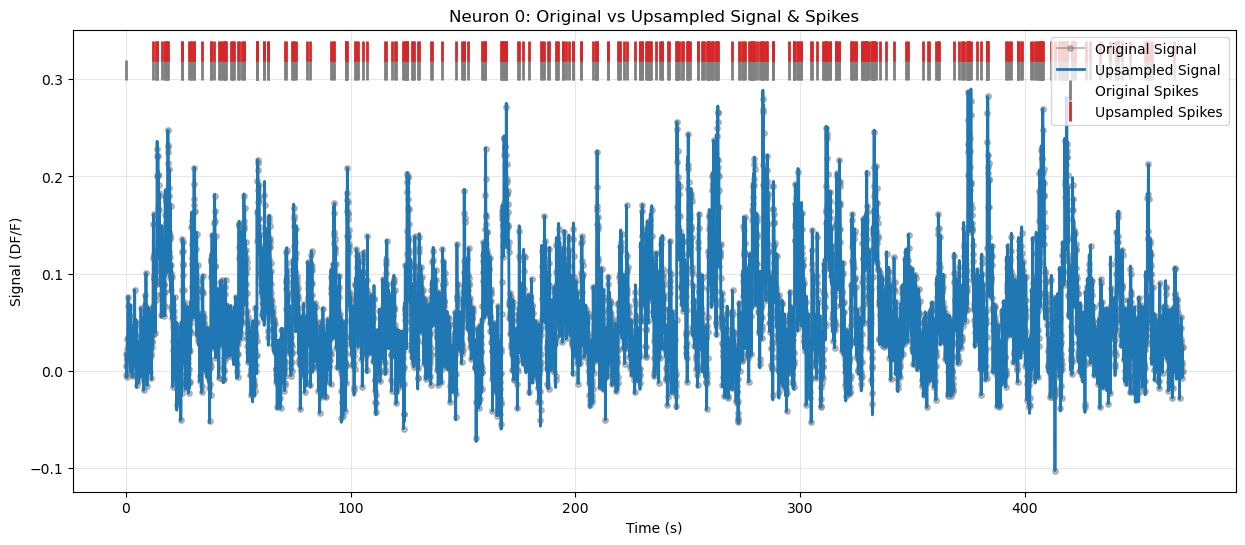

In [7]:
plot_neuron_comparison(0, data_active_neurons, upsampled_results)

## Making Neurons list:

From now on we make a list "neurons" and store everything related to each neurons n. it has original_neuron and upsampled part. any new measurement is stored in the upsampled part.

<span style="color:red">**Estimate tau by phase space method**</span>: Here we also add time constant of exponential decay estimated by phase space method.

<span style="color:red">**Important**</span>: Here I should explain the list of neurons and its components. Something like a manual of using this list and thidataset.

In [8]:
# This will hold the final list of neuron dictionaries with tau added
neurons = []

for item in upsampled_results:
    # 1. Get references to data (using the keys from upsample_v2 results)
    u_sig = item['upsampled_signal']
    u_spk_times = item['upsampled_spikes'] # times in seconds
    u_time = item['evenly_spaced_time']
    
    # 2. Determine sampling rate (fs) from the actual time vector
    if len(u_time) > 1:
        fs = 1.0 / (u_time[1] - u_time[0])
    else:
        fs = 30.0 # Default fallback
    
    t_start = u_time[0]

    # 3. Convert spike Times to Indices
    # Formula: index = (time - start_time) * fs
    u_spk_indices = ((u_spk_times - t_start) * fs).astype(int)
    
    # Filter indices to be within bounds
    u_spk_indices = u_spk_indices[(u_spk_indices >= 0) & (u_spk_indices < len(u_sig))]

    # 4. Estimate Tau
    try:
        # window_len=51, poly_order=3, cut_win=10 are standard defaults
        tau_val, fit_data = estimate_tau(u_sig, u_spk_indices, window_len=51, poly_order=3, cut_win=10)
    except Exception as e:
        print(f"Error for neuron: {e}")
        tau_val = np.nan
        fit_data = (None, None)

    # 5. Add new fields to the dictionary
    # tau_val is in frames (savgol deriv=1 uses delta=1 → derivative per sample)
    item['tau_frames'] = tau_val                   # decay constant in frames
    item['tau_ms']     = (tau_val / fs) * 1000     # decay constant in ms (fs from actual time vector)
    item['fit_data']   = fit_data
    
    # Add to our final list
    neurons.append(item)

print(f"Processed {len(neurons)} neurons. New fields 'tau_frames', 'tau_ms', and 'fit_data' added.")

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Processed 502 neurons. New fields 'tau_frames', 'tau_ms', and 'fit_data' added.


In order to have everything available in neurons list, we need a spike trains for each neuron on the evenly sampled time grid. We already have calculated it in upsampled spikes train. But, this is a binary vector, not a series of event times.

In [9]:
# Assuming 'neurons' list has been populated
for neuron in neurons:
    # 1. Get required data
    u_spk = neuron['upsampled_spikes']      # Spike times in seconds
    u_time = neuron['evenly_spaced_time']   # Time grid
    
    # 2. Generate binary spike train
    spikes_train = get_spikes_train(u_spk, u_time)
    
    # 3. Add to neuron dictionary
    neuron['spikes_train'] = spikes_train

print(f"Added 'spikes_train' to {len(neurons)} neurons.")

Added 'spikes_train' to 502 neurons.


In [10]:
# Loop through neurons and add reconstructed spikes
for n in neurons:
    # 1. Get upsampled signal and tau
    u_sig = n['upsampled_signal']
    tau = n['tau_frames']
    
    # 2. Check if tau is valid before reconstruction
    if not np.isnan(tau) and tau > 0:
        # Reconstruct spikes (returns 1D array since input is 1D)
        rec_spikes = reconstruct_spikes(u_sig, tau=tau)
        n['reconstructed_spikes'] = rec_spikes
    else:
        n['reconstructed_spikes'] = np.zeros_like(u_sig) # Or None

print("Added 'reconstructed_spikes' to neurons.")

Added 'reconstructed_spikes' to neurons.


In order to check how well the model is working, we try to chekc how we can reconstruct dF/F signals based on the estimated Tau.

In [11]:
# sampling_rate is derived per-neuron from the time vector for universality
for n in neurons:
    # 1. Retrieve Data
    true_spikes = n['original_neuron']['spikes'] # True spikes (seconds)
    rec_spikes = n.get('reconstructed_spikes')   # Reconstructed trace (continuous)
    time_grid = n['evenly_spaced_time']          # Time axis (seconds)
    tau = n.get('tau_frames')                    # Tau (frames)

    fs = 1.0 / (time_grid[1] - time_grid[0]) if len(time_grid) > 1 else 100.0

    # 2. Check Validity
    if rec_spikes is not None and tau is not None and not np.isnan(tau) and tau > 0:

        # --- Simulation A: From True Spikes ---
        sim_cal_true = simulate_calcium_from_true_spikes(
            true_spikes_sec=true_spikes,
            time_grid=time_grid,
            tau_frames=tau,
            sampling_rate=fs,
            noise_std=0.0
        )
        n['sim_calcium_from_true'] = sim_cal_true

        # --- Simulation B: From Reconstructed Spikes ---
        sim_cal_rec = simulate_calcium_from_reconstructed_spikes(
            rec_spikes=rec_spikes,
            tau_frames=tau,
            noise_std=0.0
        )
        n['sim_calcium_from_reconstructed'] = sim_cal_rec

    else:
        # Handle invalid cases
        zeros = np.zeros_like(n['upsampled_signal'])
        n['sim_calcium_from_true'] = zeros
        n['sim_calcium_from_reconstructed'] = zeros

print("Added 'sim_calcium_from_true' and 'sim_calcium_from_reconstructed' to neurons.")

Added 'sim_calcium_from_true' and 'sim_calcium_from_reconstructed' to neurons.


After checking the similarity of the true and reconstructed dF/F signals, we measure their cross-correlations and lag.

<span style="color:red">**Important**</span>:
The following code can be improved. I don't need to re-calculated reconstruced calciums. It has been already added to neurons list in upper blocks.

- Top: The Analysis checks how well the cumulative binned reconstructed spikes and true spikes train are similar.
- Button: Cumulative summation of reconstructed spikes vs. true spikes train. 

<span style="color:red">**Important**</span>:
Binary spikes train are series of events that we consider 1 at the time of events. but we don't know exact rise of the signal at the time of events. So, in order to make reconstructed spikes and true spikes train comparable after calculating the slope of the cumsum, we calibrate the reconstructed spikes by deviding it by the slope. Again, we fit a line on the cumsum of calibrated vs. true passing the origin. $R^2$ shows the  goodness of the fit. Then we add all these measurments data to the neurons list.


--- Calibration Dashboard for Neuron 470 ---


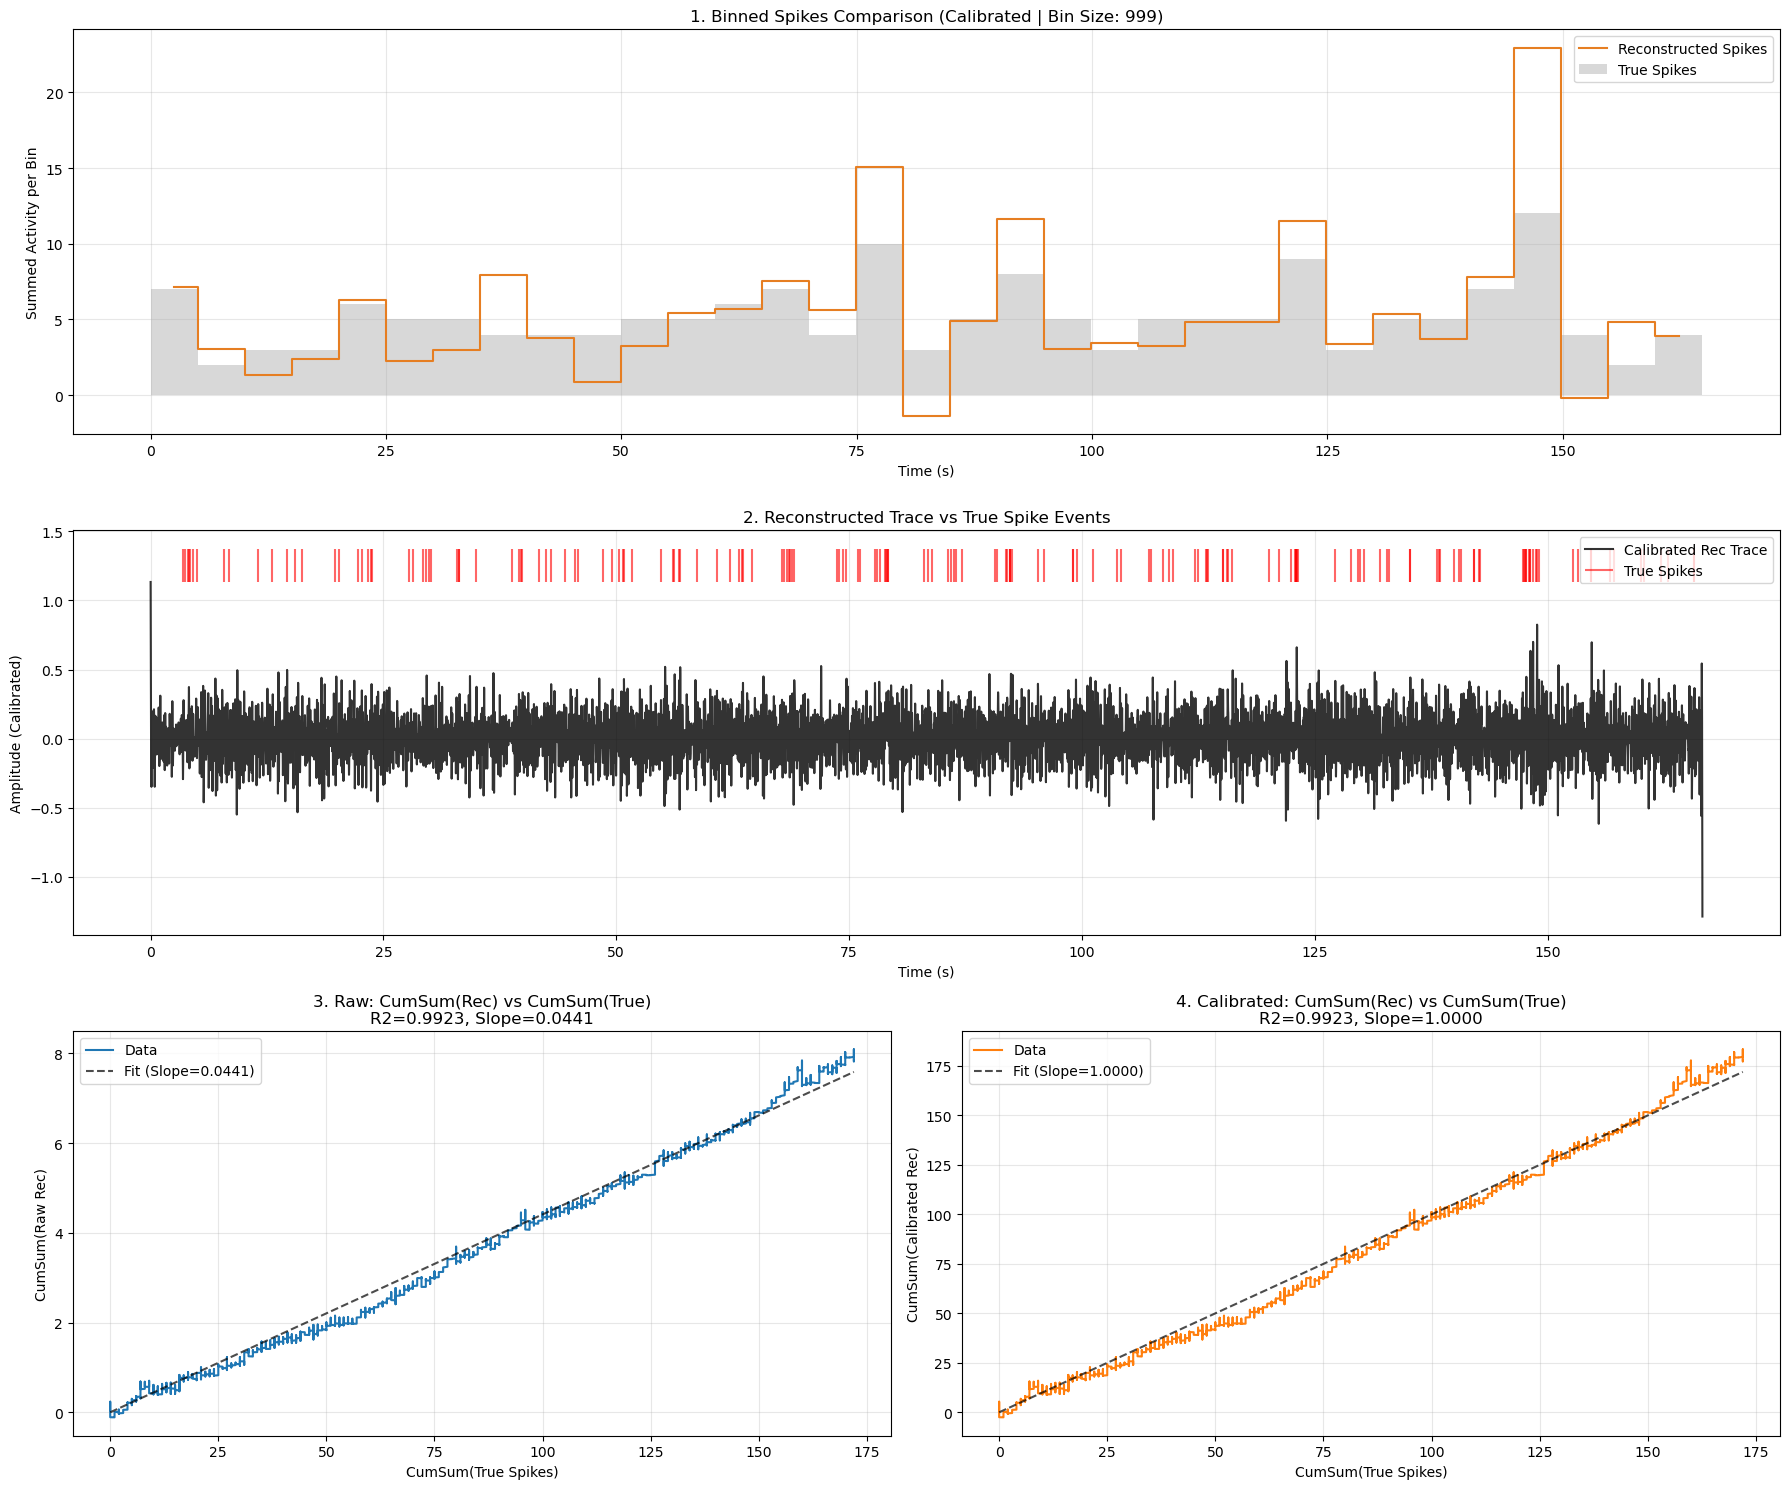

In [12]:
# --- User Configuration ---
neuron_idx = 470
bin_size_sec = 5
# --------------------------

n = neurons[neuron_idx]

# 1. Prepare Data
time_vector = n['evenly_spaced_time']
if len(time_vector) > 1:
    dt = time_vector[1] - time_vector[0]
    fs = 1.0 / dt
else:
    fs = 100.0

reconstructed_spikes = n['reconstructed_spikes']
true_spike_times = n['original_neuron']['spikes']
true_spikes_train = get_spikes_train(true_spike_times, time_vector)

# 2. Analyze
# This now uses LinearRegression(fit_intercept=False) and r2_score internally
calibration_results = analyze_cumsum_calibration(true_spikes_train, reconstructed_spikes)

# 3. Plot Dashboard
bin_size_samples = int(bin_size_sec * fs)

print(f"--- Calibration Dashboard for Neuron {neuron_idx} ---")
plot_calibration_dashboard(
    true_spikes_train, 
    reconstructed_spikes, 
    calibration_results, 
    bin_size=bin_size_samples, 
    sampling_rate=fs
)

In [13]:
# Loop through all neurons
for i, n in enumerate(neurons):
    # 1. Prepare Data
    time_vector = n['evenly_spaced_time']
    reconstructed_spikes = n['reconstructed_spikes']
    true_spike_times = n['original_neuron']['spikes']
    
    # Generate binary spike train required for analysis
    true_spikes_train = get_spikes_train(true_spike_times, time_vector)
    
    # 2. Calculate Calibration Metrics
    calibration_results = analyze_cumsum_calibration(true_spikes_train, reconstructed_spikes)
    
    # 3. Add to neuron dictionary
    n['cumsum_slope_raw']   = calibration_results['slope_raw']    # scaling factor
    n['cumsum_r2_calib']    = calibration_results['r2_calib']
    n['cumsum_slope_calib'] = calibration_results['slope_calib']
    n['calibrated_spikes']  = calibration_results['calibrated_trace']

    if i % 10 == 0:
        print(f"Processed neuron {i}: slope_raw={n['cumsum_slope_raw']:.3f}, R\u00b2_calib={n['cumsum_r2_calib']:.3f}")

print("Added 'cumsum_slope_raw', 'cumsum_r2_calib', 'cumsum_slope_calib' to all neurons.")

Processed neuron 0: slope_raw=0.029, R²_calib=0.991
Processed neuron 10: slope_raw=0.007, R²_calib=0.987
Processed neuron 20: slope_raw=0.020, R²_calib=0.986
Processed neuron 30: slope_raw=0.082, R²_calib=0.922
Processed neuron 40: slope_raw=0.069, R²_calib=0.994
Processed neuron 50: slope_raw=0.010, R²_calib=-0.062
Processed neuron 60: slope_raw=0.012, R²_calib=-0.272
Processed neuron 70: slope_raw=0.110, R²_calib=0.992
Processed neuron 80: slope_raw=0.062, R²_calib=0.781
Processed neuron 90: slope_raw=0.049, R²_calib=0.995
Processed neuron 100: slope_raw=0.052, R²_calib=0.829
Processed neuron 110: slope_raw=0.124, R²_calib=0.993
Processed neuron 120: slope_raw=0.199, R²_calib=0.995
Processed neuron 130: slope_raw=0.362, R²_calib=0.720
Processed neuron 140: slope_raw=0.488, R²_calib=0.951
Processed neuron 150: slope_raw=0.286, R²_calib=0.992
Processed neuron 160: slope_raw=0.534, R²_calib=0.977
Processed neuron 170: slope_raw=0.658, R²_calib=0.997
Processed neuron 180: slope_raw=0.137

In [14]:
# ── Pearson & Spearman on cumsum(true) vs cumsum(reconstructed) ───────────────

for i, n in enumerate(neurons):
    time_vector          = n['evenly_spaced_time']
    reconstructed_spikes = n['reconstructed_spikes']
    true_spike_times     = n['original_neuron']['spikes']
    true_spikes_train    = get_spikes_train(true_spike_times, time_vector)

    corr = compute_cumsum_correlation_metrics(true_spikes_train, reconstructed_spikes)
    n['pearson_cumsum_raw']    = corr['pearson_cumsum_raw']
    n['pearson_cumsum_calib']  = corr['pearson_cumsum_calib']
    n['spearman_cumsum_raw']   = corr['spearman_cumsum_raw']
    n['spearman_cumsum_calib'] = corr['spearman_cumsum_calib']

print(f"Added pearson/spearman cumsum metrics to {len(neurons)} neurons.")


Added pearson/spearman cumsum metrics to 502 neurons.


### Blind deconvolution

In [15]:
import nitime.algorithms as tsa
from scipy.optimize import curve_fit
from tqdm import tqdm
import numpy as np

def lorentzian(f, A, tau, white_noise):
    return A / (1 + (2 * np.pi * f * tau)**2) + white_noise

f_starts = [0.5, 1.0, 1.5]
f_end = 30.0

for i, n in enumerate(tqdm(neurons, desc="PSD Lorentzian fit")):
    time_vector = n['evenly_spaced_time']
    fs = 1.0 / (time_vector[1] - time_vector[0]) if len(time_vector) > 1 else 200.0
    signal = n['upsampled_signal']

    try:
        freq_tsa, psd_tsa, _ = tsa.multi_taper_psd(signal, Fs=fs)
    except Exception as e:
        n['tau_psd_frames'] = np.nan
        n['tau_psd_ms']     = np.nan
        n['psd_fit_info'] = {'status': f'PSD failed: {e}'}
        continue

    fit_success = False
    for f_min in f_starts:
        mask = (freq_tsa >= f_min) & (freq_tsa <= f_end)
        f_fit = freq_tsa[mask]
        psd_fit = psd_tsa[mask]

        finite_mask = np.isfinite(f_fit) & np.isfinite(psd_fit)
        f_fit = f_fit[finite_mask]
        psd_fit = psd_fit[finite_mask]

        if len(f_fit) < 4:
            continue

        p0 = [psd_fit[0], 0.1, np.min(psd_fit)]
        bounds = ([0, 1e-5, 0], [np.inf, 10.0, np.inf])

        try:
            popt, pcov = curve_fit(
                lorentzian, f_fit, psd_fit,
                p0=p0, bounds=bounds, maxfev=5000
            )
            A_fit, tau_fit_sec, C_fit = popt
            tau_fit_frames = tau_fit_sec * fs  # convert to frames (fs from actual time vector)

            psd_pred = lorentzian(f_fit, *popt)
            ss_res = np.sum((psd_fit - psd_pred) ** 2)
            ss_tot = np.sum((psd_fit - np.mean(psd_fit)) ** 2)
            r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

            perr = np.sqrt(np.diag(pcov)) if np.all(np.isfinite(pcov)) else [np.nan] * 3

            n['tau_psd_frames'] = tau_fit_frames        # decay constant in frames
            n['tau_psd_ms']     = tau_fit_sec * 1000    # decay constant in ms
            n['psd_fit_info'] = {
                'status':        'ok',
                'f_min':         f_min,
                'f_max':         f_end,
                'A':             A_fit,
                'tau_sec':       tau_fit_sec,
                'tau_frames':    tau_fit_frames,
                'tau_ms':        tau_fit_sec * 1000,
                'white_noise':   C_fit,
                'r_squared':     r_squared,
                'std_A':         perr[0],
                'std_tau':       perr[1],
                'std_wn':        perr[2],
            }
            fit_success = True
            break

        except RuntimeError:
            continue

    if not fit_success:
        n['tau_psd_frames'] = np.nan
        n['tau_psd_ms']     = np.nan
        n['psd_fit_info'] = {'status': 'fit_failed', 'f_starts_tried': f_starts}

# --- Summary ---
tau_psd_values = [n.get('tau_psd_frames', np.nan) for n in neurons]
n_total   = len(neurons)
n_ok      = sum(1 for n in neurons if n.get('psd_fit_info', {}).get('status') == 'ok')
n_failed  = sum(1 for n in neurons if n.get('psd_fit_info', {}).get('status') == 'fit_failed')
n_psd_err = sum(1 for n in neurons if str(n.get('psd_fit_info', {}).get('status', '')).startswith('PSD failed'))
n_nan     = sum(1 for v in tau_psd_values if np.isnan(v))
n_inf     = sum(1 for v in tau_psd_values if np.isinf(v))

print(f"\n{'='*40}")
print(f"Total neurons      : {n_total}")
print(f"Fit OK             : {n_ok}")
print(f"Fit failed         : {n_failed}")
print(f"PSD errors         : {n_psd_err}")
print(f"tau_psd_frames = NaN : {n_nan}")
print(f"tau_psd_frames = Inf : {n_inf}")
print(f"{'='*40}")

PSD Lorentzian fit: 100%|██████████| 502/502 [05:19<00:00,  1.57it/s]


Total neurons      : 502
Fit OK             : 501
Fit failed         : 1
PSD errors         : 0
tau_psd_frames = NaN : 1
tau_psd_frames = Inf : 0


In [16]:
# Add reconstructed_spikes_psd using tau_psd_frames
for n in neurons:
    u_sig = n['upsampled_signal']
    tau_psd_frames = n.get('tau_psd_frames')

    if tau_psd_frames is not None and not np.isnan(tau_psd_frames) and tau_psd_frames > 0:
        n['reconstructed_spikes_psd'] = reconstruct_spikes(u_sig, tau=tau_psd_frames)
    else:
        n['reconstructed_spikes_psd'] = np.zeros_like(u_sig)

print("Added 'reconstructed_spikes_psd' to neurons.")

Added 'reconstructed_spikes_psd' to neurons.


In [17]:
# Cumsum calibration for reconstructed_spikes_psd
for i, n in enumerate(neurons):
    time_vector          = n['evenly_spaced_time']
    rec_spikes_psd       = n['reconstructed_spikes_psd']
    true_spike_times     = n['original_neuron']['spikes']

    true_spikes_train = get_spikes_train(true_spike_times, time_vector)

    calibration_results = analyze_cumsum_calibration(true_spikes_train, rec_spikes_psd)

    n['cumsum_slope_raw_psd']   = calibration_results['slope_raw']
    n['cumsum_r2_calib_psd']    = calibration_results['r2_calib']
    n['cumsum_slope_calib_psd'] = calibration_results['slope_calib']
    n['calibrated_spikes_psd']  = calibration_results['calibrated_trace']

    if i % 10 == 0:
        print(f"Processed neuron {i}: slope_raw={n['cumsum_slope_raw_psd']:.3f}, R²={n['cumsum_r2_calib_psd']:.3f}")

print("Added 'cumsum_slope_raw_psd', 'cumsum_r2_calib_psd', 'cumsum_slope_calib_psd' to all neurons.")


Processed neuron 0: slope_raw=0.326, R²=0.992
Processed neuron 10: slope_raw=0.111, R²=0.986
Processed neuron 20: slope_raw=1.533, R²=0.990
Processed neuron 30: slope_raw=0.025, R²=0.227
Processed neuron 40: slope_raw=0.039, R²=0.973
Processed neuron 50: slope_raw=1.163, R²=0.996
Processed neuron 60: slope_raw=0.020, R²=0.783
Processed neuron 70: slope_raw=0.567, R²=0.997
Processed neuron 80: slope_raw=0.035, R²=0.533
Processed neuron 90: slope_raw=0.131, R²=0.992
Processed neuron 100: slope_raw=0.010, R²=0.358
Processed neuron 110: slope_raw=0.281, R²=0.993
Processed neuron 120: slope_raw=0.511, R²=0.995
Processed neuron 130: slope_raw=0.614, R²=0.721
Processed neuron 140: slope_raw=0.789, R²=0.952
Processed neuron 150: slope_raw=0.160, R²=0.992
Processed neuron 160: slope_raw=0.318, R²=0.977
Processed neuron 170: slope_raw=0.135, R²=0.898
Processed neuron 180: slope_raw=0.029, R²=0.945
Processed neuron 190: slope_raw=0.093, R²=0.935
Processed neuron 200: slope_raw=0.037, R²=0.994
Pro

In [18]:
# ── Pearson & Spearman on cumsum(true) vs cumsum(reconstructed_psd) ─────────

for i, n in enumerate(neurons):
    time_vector       = n['evenly_spaced_time']
    rec_spikes_psd    = n.get('reconstructed_spikes_psd')
    true_spike_times  = n['original_neuron']['spikes']
    true_spikes_train = get_spikes_train(true_spike_times, time_vector)

    if rec_spikes_psd is None:
        for key in ['pearson_cumsum_raw_psd', 'pearson_cumsum_calib_psd',
                    'spearman_cumsum_raw_psd', 'spearman_cumsum_calib_psd']:
            n[key] = np.nan
        continue

    corr = compute_cumsum_correlation_metrics(true_spikes_train, rec_spikes_psd)
    n['pearson_cumsum_raw_psd']    = corr['pearson_cumsum_raw']
    n['pearson_cumsum_calib_psd']  = corr['pearson_cumsum_calib']
    n['spearman_cumsum_raw_psd']   = corr['spearman_cumsum_raw']
    n['spearman_cumsum_calib_psd'] = corr['spearman_cumsum_calib']

print(f"Added pearson/spearman cumsum PSD metrics to {len(neurons)} neurons.")


Added pearson/spearman cumsum PSD metrics to 502 neurons.


In [19]:
# Add sim_calcium_from_rec_psd using tau_psd_frames
for n in neurons:
    rec_spikes_psd = n.get('reconstructed_spikes_psd')
    tau_psd_frames = n.get('tau_psd_frames')

    if rec_spikes_psd is not None and tau_psd_frames is not None and not np.isnan(tau_psd_frames) and tau_psd_frames > 0:
        n['sim_calcium_from_rec_psd'] = simulate_calcium_from_reconstructed_spikes(
            rec_spikes_psd,
            tau_frames=tau_psd_frames,
        )
    else:
        n['sim_calcium_from_rec_psd'] = None

print("Added 'sim_calcium_from_rec_psd' to neurons.")

Added 'sim_calcium_from_rec_psd' to neurons.


In [20]:
# Add sim_calcium_from_true_psd using true spikes + tau_psd_frames
for n in neurons:
    true_spikes = n['original_neuron']['spikes']
    time_grid   = n['evenly_spaced_time']
    tau_psd     = n.get('tau_psd_frames')

    if len(time_grid) > 1:
        fs = 1.0 / (time_grid[1] - time_grid[0])
    else:
        fs = 100.0

    if tau_psd is not None and not np.isnan(tau_psd) and tau_psd > 0:
        n['sim_calcium_from_true_psd'] = simulate_calcium_from_true_spikes(
            true_spikes_sec=true_spikes,
            time_grid=time_grid,
            tau_frames=tau_psd,
            sampling_rate=fs,
            noise_std=0.0
        )
    else:
        n['sim_calcium_from_true_psd'] = np.zeros_like(n['upsampled_signal'])

print("Added 'sim_calcium_from_true_psd' to neurons.")


Added 'sim_calcium_from_true_psd' to neurons.


In [21]:
from scipy.optimize import minimize_scalar
from scipy.stats import pearsonr

# --- Scaling functions ---
def ols_scale(original, sim):
    return np.dot(sim, original) / np.dot(sim, sim)

def lad_scale(original, sim):
    result = minimize_scalar(
        lambda a: np.sum(np.abs(original - a * sim)),
        bounds=(0.01, 100), method='bounded'
    )
    return result.x

# --- GOF metrics ---
def compute_gof(original, sim):
    metrics = {}

    # MSE
    metrics['mse'] = np.mean((original - sim) ** 2)

    # RMSE
    metrics['rmse'] = np.sqrt(metrics['mse'])

    # R²
    ss_res = np.sum((original - sim) ** 2)
    ss_tot = np.sum((original - np.mean(original)) ** 2)
    metrics['r_squared'] = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return metrics

In [22]:
# --- Main loop: GOF for all 4 calcium variants ---
for n in neurons:
    original = n['upsampled_signal']

    for sim_key, gof_key in [
        ('sim_calcium_from_true',          'gof_tau_true'),
        ('sim_calcium_from_reconstructed', 'gof_tau'),
        ('sim_calcium_from_true_psd',      'gof_tau_psd_true'),
        ('sim_calcium_from_rec_psd',       'gof_tau_psd'),
    ]:
        sim = n.get(sim_key)

        if sim is None or np.all(sim == 0) or np.std(sim) == 0:
            n[gof_key] = None
            continue

        gof = {}

        gof['no_scale'] = compute_gof(original, sim)

        a_ols = ols_scale(original, sim)
        gof['ols'] = compute_gof(original, a_ols * sim)
        gof['ols']['scale_factor'] = a_ols

        a_lad = lad_scale(original, sim)
        gof['lad'] = compute_gof(original, a_lad * sim)
        gof['lad']['scale_factor'] = a_lad

        n[gof_key] = gof

print("Added 'gof_tau_true', 'gof_tau', 'gof_tau_psd_true', 'gof_tau_psd' to neurons.")


Added 'gof_tau_true', 'gof_tau', 'gof_tau_psd_true', 'gof_tau_psd' to neurons.


--- PSD vs True Spikes | Neuron 4 ---


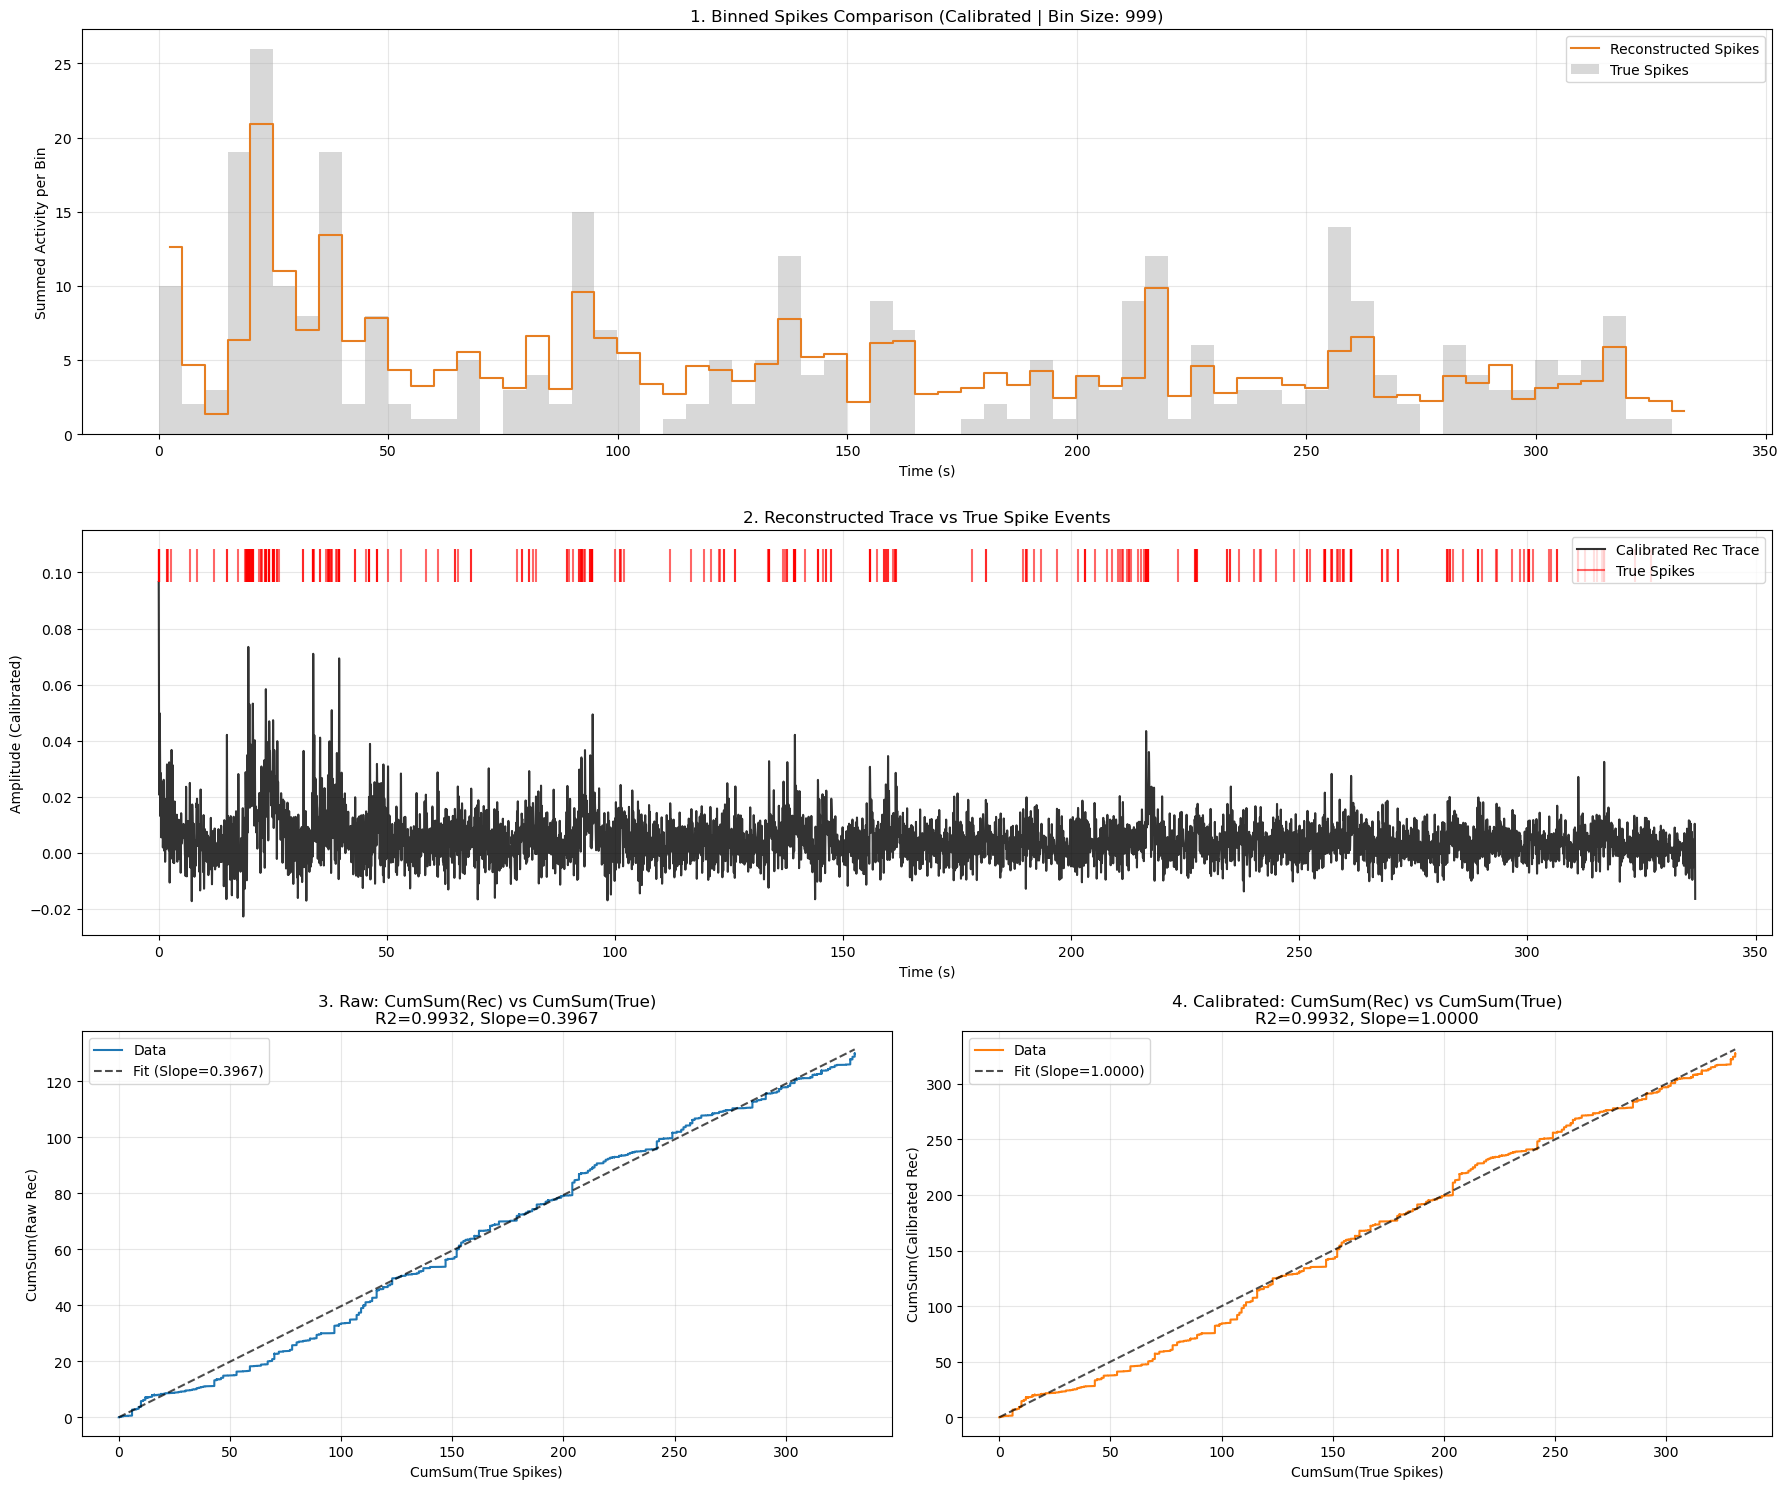

--- PSD vs Derivative | Neuron 4 ---


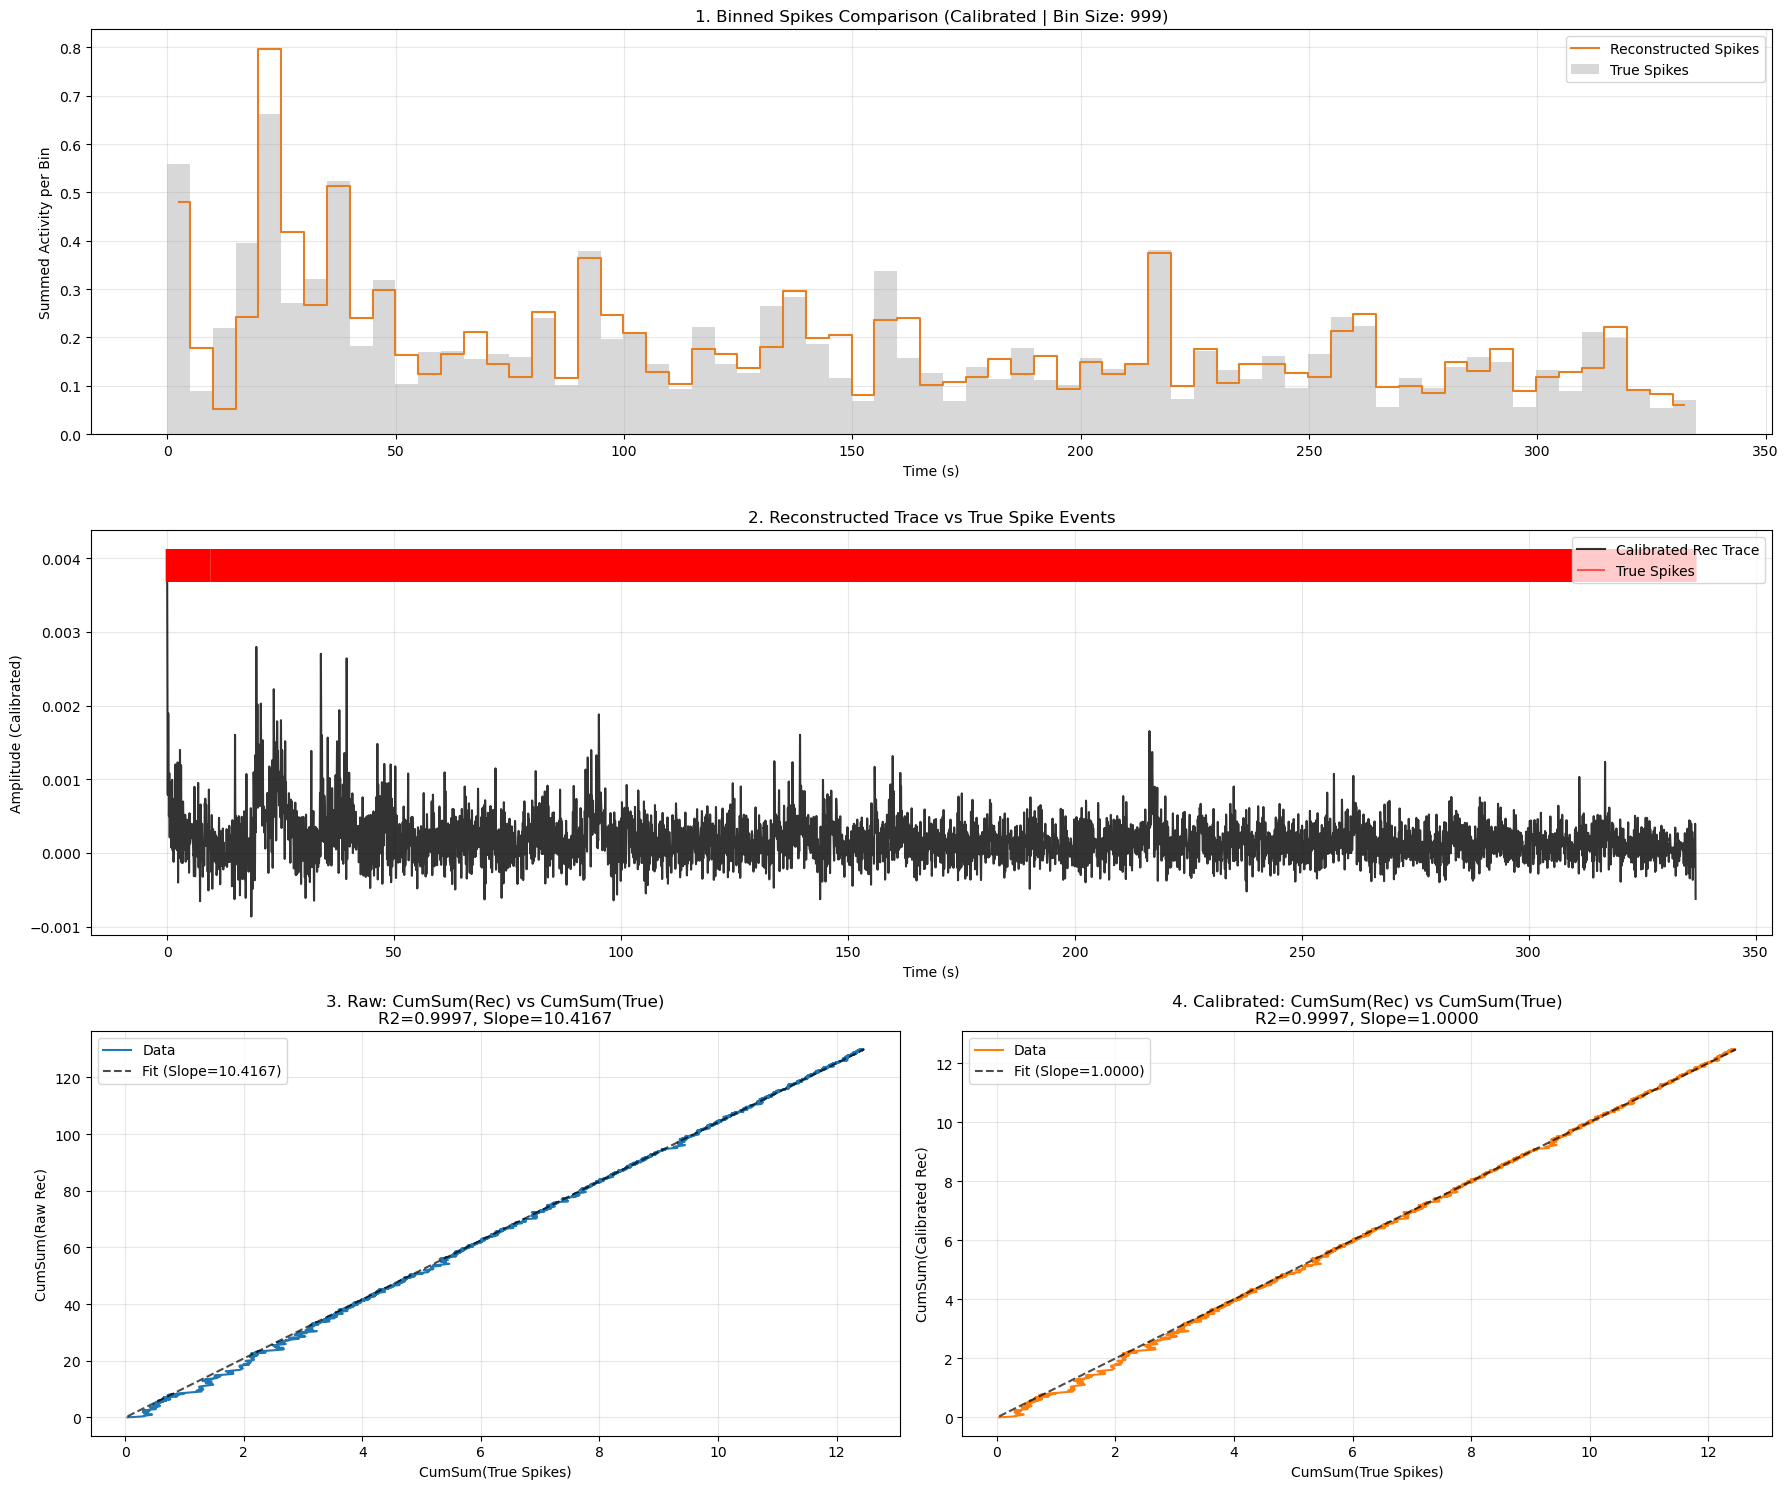

In [23]:
# --- User Configuration ---
neuron_idx = 4
bin_size_sec = 5
# --------------------------

n = neurons[neuron_idx]

time_vector = n['evenly_spaced_time']
if len(time_vector) > 1:
    dt = time_vector[1] - time_vector[0]
    fs = 1.0 / dt
else:
    fs = 100.0

reconstructed_spikes     = n['reconstructed_spikes']
reconstructed_spikes_psd = n['reconstructed_spikes_psd']
true_spike_times         = n['original_neuron']['spikes']
true_spikes_train        = get_spikes_train(true_spike_times, time_vector)

bin_size_samples = int(bin_size_sec * fs)

# ── Comparison 1: PSD reconstruction vs True spikes ──────────────────────────
cal_psd_vs_true = analyze_cumsum_calibration(true_spikes_train, reconstructed_spikes_psd)
print(f"--- PSD vs True Spikes | Neuron {neuron_idx} ---")
plot_calibration_dashboard(
    true_spikes_train,
    reconstructed_spikes_psd,
    cal_psd_vs_true,
    bin_size=bin_size_samples,
    sampling_rate=fs
)

# ── Comparison 2: PSD reconstruction vs Derivative reconstruction ─────────────
cal_psd_vs_deriv = analyze_cumsum_calibration(reconstructed_spikes, reconstructed_spikes_psd)
print(f"--- PSD vs Derivative | Neuron {neuron_idx} ---")
plot_calibration_dashboard(
    reconstructed_spikes,
    reconstructed_spikes_psd,
    cal_psd_vs_deriv,
    bin_size=bin_size_samples,
    sampling_rate=fs
)


In [24]:
for i, n in enumerate(neurons):
    time_vector              = n['evenly_spaced_time']
    reconstructed_spikes     = n['reconstructed_spikes']
    reconstructed_spikes_psd = n.get('reconstructed_spikes_psd')
    true_spike_times         = n['original_neuron']['spikes']
    true_spikes_train        = get_spikes_train(true_spike_times, time_vector)

    if reconstructed_spikes_psd is None:
        for key in ['cumsum_psd_vs_true_slope_raw',  'cumsum_psd_vs_true_r2_calib',  'cumsum_psd_vs_true_slope_calib',
                    'cumsum_psd_vs_deriv_slope_raw', 'cumsum_psd_vs_deriv_r2_calib', 'cumsum_psd_vs_deriv_slope_calib']:
            n[key] = np.nan
        continue

    # PSD reconstruction vs True spikes
    cal_psd_vs_true = analyze_cumsum_calibration(true_spikes_train, reconstructed_spikes_psd)
    n['cumsum_psd_vs_true_slope_raw']   = cal_psd_vs_true['slope_raw']
    n['cumsum_psd_vs_true_r2_calib']    = cal_psd_vs_true['r2_calib']
    n['cumsum_psd_vs_true_slope_calib'] = cal_psd_vs_true['slope_calib']

    # PSD reconstruction vs Derivative reconstruction
    cal_psd_vs_deriv = analyze_cumsum_calibration(reconstructed_spikes, reconstructed_spikes_psd)
    n['cumsum_psd_vs_deriv_slope_raw']   = cal_psd_vs_deriv['slope_raw']
    n['cumsum_psd_vs_deriv_r2_calib']    = cal_psd_vs_deriv['r2_calib']
    n['cumsum_psd_vs_deriv_slope_calib'] = cal_psd_vs_deriv['slope_calib']

    if i % 10 == 0:
        print(f"Neuron {i}: PSD-vs-True R²={n['cumsum_psd_vs_true_r2_calib']:.3f}  |  PSD-vs-Deriv R²={n['cumsum_psd_vs_deriv_r2_calib']:.3f}")

print("Done: 'cumsum_psd_vs_true_*' and 'cumsum_psd_vs_deriv_*' added to all neurons.")


Neuron 0: PSD-vs-True R²=0.992  |  PSD-vs-Deriv R²=1.000
Neuron 10: PSD-vs-True R²=0.986  |  PSD-vs-Deriv R²=1.000
Neuron 20: PSD-vs-True R²=0.990  |  PSD-vs-Deriv R²=0.994
Neuron 30: PSD-vs-True R²=0.227  |  PSD-vs-Deriv R²=0.744
Neuron 40: PSD-vs-True R²=0.973  |  PSD-vs-Deriv R²=0.992
Neuron 50: PSD-vs-True R²=0.996  |  PSD-vs-Deriv R²=-0.559
Neuron 60: PSD-vs-True R²=0.783  |  PSD-vs-Deriv R²=0.850
Neuron 70: PSD-vs-True R²=0.997  |  PSD-vs-Deriv R²=0.995
Neuron 80: PSD-vs-True R²=0.533  |  PSD-vs-Deriv R²=0.960
Neuron 90: PSD-vs-True R²=0.992  |  PSD-vs-Deriv R²=0.999
Neuron 100: PSD-vs-True R²=0.358  |  PSD-vs-Deriv R²=0.871
Neuron 110: PSD-vs-True R²=0.993  |  PSD-vs-Deriv R²=1.000
Neuron 120: PSD-vs-True R²=0.995  |  PSD-vs-Deriv R²=1.000
Neuron 130: PSD-vs-True R²=0.721  |  PSD-vs-Deriv R²=1.000
Neuron 140: PSD-vs-True R²=0.952  |  PSD-vs-Deriv R²=1.000
Neuron 150: PSD-vs-True R²=0.992  |  PSD-vs-Deriv R²=1.000
Neuron 160: PSD-vs-True R²=0.977  |  PSD-vs-Deriv R²=1.000
Neuron 

**Dataframe of the active neurons**

In [25]:
df = pd.DataFrame(neurons)
df.head()

,original_neuron,upsampled_signal,upsampled_spikes,evenly_spaced_time,tau_frames,tau_ms,fit_data,spikes_train,reconstructed_spikes,sim_calcium_from_true,...,gof_tau_true,gof_tau,gof_tau_psd_true,gof_tau_psd,cumsum_psd_vs_true_slope_raw,cumsum_psd_vs_true_r2_calib,cumsum_psd_vs_true_slope_calib,cumsum_psd_vs_deriv_slope_raw,cumsum_psd_vs_deriv_r2_calib,cumsum_psd_vs_deriv_slope_calib
0,"{'global_id': 0, 'dataset_name': 'DS01-OGB1-m-...","[0.01746, 0.017331935724489985, 0.017083998689...","[12.058, 13.597, 13.781, 13.791, 15.925, 17.48...","[0.08213552361396304, 0.08713558606015778, 0.0...",550.039799,2750.233344,"([0.019783096164531812, 0.018874787353773688, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-3.355950221055251e-05, -0.000157902942976671...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"{'no_scale': {'mse': 6.375316772178215, 'rmse'...","{'no_scale': {'mse': 2.611720245495947e-06, 'r...","{'no_scale': {'mse': 0.15065992182006124, 'rms...","{'no_scale': {'mse': 2.4250566262677787e-06, '...",0.325780,0.991721,1.0,11.173413,0.999699,1.0
1,"{'global_id': 2, 'dataset_name': 'DS01-OGB1-m-...","[0.033982, 0.03457941600811627, 0.035215146014...","[1.1814, 3.1747, 5.6838, 9.8526, 11.499, 23.72...","[0.08720676724513822, 0.09220684773337812, 0.0...",482.954466,2414.811204,"([0.032076448584631864, 0.033303577557799995, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0006471438610686231, 0.0006889116952857995,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"{'no_scale': {'mse': 6.618122720596277, 'rmse'...","{'no_scale': {'mse': 5.20671470081054e-06, 'rm...","{'no_scale': {'mse': 0.128754921427849, 'rmse'...","{'no_scale': {'mse': 3.0758192425334605e-06, '...",0.526975,0.978507,1.0,17.759054,0.999643,1.0
2,"{'global_id': 3, 'dataset_name': 'DS01-OGB1-m-...","[-0.018393, -0.02123096221046043, -0.023478207...","[1.3502, 1.4418, 1.471, 1.4833, 1.612, 1.6975,...","[0.09152480322167307, 0.09652501667326668, 0.1...",4308.220502,21542.022104,"([-0.02076025160396994, -0.022825709833421443,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.003147332126261497, -0.002542660762152697,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"{'no_scale': {'mse': 3873.180148840169, 'rmse'...","{'no_scale': {'mse': 1.5364459626189208e-05, '...","{'no_scale': {'mse': 0.4582410730789882, 'rmse...","{'no_scale': {'mse': 2.812134764757235e-06, 'r...",0.125394,0.956802,1.0,148.363722,0.907232,1.0
3,"{'global_id': 4, 'dataset_name': 'DS01-OGB1-m-...","[0.093936, 0.08504650475216656, 0.077235136071...","[0.83541, 0.9900899999999999, 1.0474, 1.7466, ...","[0.08213552361396304, 0.08713566084208207, 0.0...",611.888498,3059.526458,"([0.08660761927991652, 0.08017946564116409, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.009291744324784506, -0.008203089784567758,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"{'no_scale': {'mse': 19.088411795711423, 'rmse...","{'no_scale': {'mse': 6.100186112780202e-05, 'r...","{'no_scale': {'mse': 0.14839366308477903, 'rms...","{'no_scale': {'mse': 8.043187241479346e-06, 'r...",0.389243,0.998282,1.0,23.536365,0.998730,1.0
4,"{'global_id': 5, 'dataset_name': 'DS01-OGB1-m-...","[-0.0037896, 0.03306084771774832, 0.0667524698...","[0.093371, 0.12829, 0.18387, 0.1978, 0.2332, 0...","[0.08366800535475234, 0.08866813484878923, 0.0...",265.680246,1328.435632,"([0.3114548659183488, 0.3161146921091283, 0.32...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.03845941002689128, 0.035373566778092363, 0....","[0.0, 1.0, 0.9962431516303121, 0.9925004171702...",...,"{'no_scale': {'mse': 5.821257201294921, 'rmse'...","{'no_scale': {'mse': 3.019829246503609e-06, 'r...","{'no_scale': {'mse': 0.2067437485676965, 'rmse...","{'no_scale': {'mse': 4.030184864529114e-06, 'r...",0.396716,0.993152,1.0,10.416694,0.999690,1.0


In [26]:
import numpy as np

def _neuron_metrics(n):
    spikes = np.sort(n['original_neuron']['spikes'])
    time   = n['evenly_spaced_time']
    duration = time[-1] - time[0]
    n_spikes = len(spikes)

    firing_rate = n_spikes / duration if duration > 0 else np.nan

    if n_spikes > 1:
        isis = np.diff(spikes)           # inter-spike intervals in seconds
        mean_isi = np.mean(isis)

        # CV2: local irregularity (Holt et al. 1996)
        # CV2_i = 2|ISI_{i+1} - ISI_i| / (ISI_{i+1} + ISI_i)
        if len(isis) > 1:
            cv2 = np.mean(2 * np.abs(np.diff(isis)) / (isis[:-1] + isis[1:]))
        else:
            cv2 = np.nan

        # Burst index: fraction of ISIs shorter than half the mean ISI
        burst_index = np.mean(isis < mean_isi / 2)
    else:
        mean_isi   = np.nan
        cv2        = np.nan
        burst_index = np.nan

    return firing_rate, mean_isi, cv2, burst_index

firing_rates, mean_isis, cv2s, burst_indices = zip(*[_neuron_metrics(n) for n in neurons])

df['firing_rate_hz'] = firing_rates
df['mean_isi_s']     = mean_isis
df['cv2']            = cv2s
df['burst_index']    = burst_indices   # fraction of ISIs < half mean ISI

df[['firing_rate_hz', 'mean_isi_s', 'cv2', 'burst_index']].head()

/tmp/ipykernel_27770/2543772090.py:18: RuntimeWarning: invalid value encountered in divide
  cv2 = np.mean(2 * np.abs(np.diff(isis)) / (isis[:-1] + isis[1:]))


,firing_rate_hz,mean_isi_s,cv2,burst_index
0,0.763463,1.303450,1.292421,0.547486
1,0.793060,1.263130,NaN,0.604096
2,2.767983,0.302705,1.232606,0.654174
3,1.268472,0.779363,1.305788,0.556923
4,1.074938,0.906078,NaN,0.637119


In [27]:
df['global_id']    = df['original_neuron'].apply(lambda x: x.get('global_id'))
df['dataset_name'] = df['original_neuron'].apply(lambda x: x.get('dataset_name'))
df['frame_rate']   = df['original_neuron'].apply(lambda x: x.get('frame_rate'))


In [28]:
signal_cols = [
    'upsampled_signal',
    'upsampled_spikes',
    'evenly_spaced_time',
    'fit_data',
    'spikes_train',
    'reconstructed_spikes',
    'reconstructed_spikes_psd',
    'sim_calcium_from_true',
    'sim_calcium_from_reconstructed',
    'sim_calcium_from_rec_psd',
    'sim_calcium_from_true_psd',
    'calibrated_spikes',
    'calibrated_spikes_psd',
    'gof_tau_true',
    'gof_tau_psd_true',
    'original_neuron',
]

df_measurements = df.copy()

df_measurements['gof_tau_r2']     = df_measurements['gof_tau'].apply(lambda x: x['ols']['r_squared'] if x is not None else np.nan)
df_measurements['gof_tau_psd_r2'] = df_measurements['gof_tau_psd'].apply(lambda x: x['ols']['r_squared'] if x is not None else np.nan)

df_measurements['psd_fit_r2']      = df_measurements['psd_fit_info'].apply(lambda x: x.get('r_squared', np.nan) if isinstance(x, dict) else np.nan)
df_measurements['psd_fit_std_tau'] = df_measurements['psd_fit_info'].apply(lambda x: x.get('std_tau', np.nan) if isinstance(x, dict) else np.nan)

df_measurements = df_measurements.drop(columns=signal_cols + ['gof_tau', 'gof_tau_psd', 'psd_fit_info'], errors='ignore')

print(df_measurements.shape)
print(df_measurements.columns.tolist())

(502, 35)
['tau_frames', 'tau_ms', 'cumsum_slope_raw', 'cumsum_r2_calib', 'cumsum_slope_calib', 'pearson_cumsum_raw', 'pearson_cumsum_calib', 'spearman_cumsum_raw', 'spearman_cumsum_calib', 'tau_psd_frames', 'tau_psd_ms', 'cumsum_slope_raw_psd', 'cumsum_r2_calib_psd', 'cumsum_slope_calib_psd', 'pearson_cumsum_raw_psd', 'pearson_cumsum_calib_psd', 'spearman_cumsum_raw_psd', 'spearman_cumsum_calib_psd', 'cumsum_psd_vs_true_slope_raw', 'cumsum_psd_vs_true_r2_calib', 'cumsum_psd_vs_true_slope_calib', 'cumsum_psd_vs_deriv_slope_raw', 'cumsum_psd_vs_deriv_r2_calib', 'cumsum_psd_vs_deriv_slope_calib', 'firing_rate_hz', 'mean_isi_s', 'cv2', 'burst_index', 'global_id', 'dataset_name', 'frame_rate', 'gof_tau_r2', 'gof_tau_psd_r2', 'psd_fit_r2', 'psd_fit_std_tau']


In [29]:
df_measurements.head()

,tau_frames,tau_ms,cumsum_slope_raw,cumsum_r2_calib,cumsum_slope_calib,pearson_cumsum_raw,pearson_cumsum_calib,spearman_cumsum_raw,spearman_cumsum_calib,tau_psd_frames,...,mean_isi_s,cv2,burst_index,global_id,dataset_name,frame_rate,gof_tau_r2,gof_tau_psd_r2,psd_fit_r2,psd_fit_std_tau
0,550.039799,2750.233344,0.029152,0.990673,1.0,0.998603,0.998603,0.999838,0.999838,48.948037,...,1.303450,1.292421,0.547486,0,DS01-OGB1-m-V1,12.175,0.999061,0.999309,0.798573,0.003241
1,482.954466,2414.811204,0.029673,0.978774,1.0,0.995776,0.995776,0.999724,0.999724,27.083588,...,1.263130,NaN,0.604096,2,DS01-OGB1-m-V1,11.467,0.997197,0.998957,0.766753,0.001677
2,4308.220502,21542.022104,0.000832,0.889661,1.0,0.948893,0.948893,0.964475,0.964475,23.562661,...,0.302705,1.232606,0.654174,3,DS01-OGB1-m-V1,10.926,0.991138,0.999131,0.690532,0.002269
3,611.888498,3059.526458,0.016534,0.997858,1.0,0.999008,0.999008,0.999402,0.999402,26.197844,...,0.779363,1.305788,0.556923,4,DS01-OGB1-m-V1,12.175,0.980451,0.998132,0.803980,0.001733
4,265.680246,1328.435632,0.038086,0.993795,1.0,0.996932,0.996932,0.999789,0.999789,25.336750,...,0.906078,NaN,0.637119,5,DS01-OGB1-m-V1,11.952,0.998908,0.999172,0.638313,0.002223


In [31]:
n0 = neurons[0]
original = n0['upsampled_signal']
sim = n0.get('sim_calcium_from_reconstructed')
print(f"sim is None: {sim is None}")
if sim is not None:
    sim_arr = np.asarray(sim)
    print(f"shape: {sim_arr.shape}, std: {np.std(sim_arr):.4f}, all_zero: {np.all(sim_arr == 0)}")
    corr = compute_signal_correlation_metrics(original, sim_arr)
    print(corr)


sim is None: False
shape: (94045,), std: 0.0527, all_zero: False
{'pearson_raw': 0.9995306224227213, 'pearson_scaled': 0.999530622422721, 'spearman_raw': 0.9992664405114913, 'spearman_scaled': 0.9992664405114913}


In [32]:
# ── Add chi_squared and NMSE to all GOF dictionaries, then update df_measurements ──

import numpy as np
import pandas as pd

def _add_chi2_nmse(sub_dict, y_true, y_pred):
    eps = 1e-10
    sub_dict['chi_squared'] = float(np.sum((y_true - y_pred) ** 2 / (np.abs(y_pred) + eps)))
    mse = np.mean((y_true - y_pred) ** 2)
    var_true = np.var(y_true, ddof=1)
    sub_dict['nmse'] = float(mse / var_true) if var_true > 0 else np.nan

for n in neurons:
    y_true = n['upsampled_signal']

    for sim_key, gof_key in [
        ('sim_calcium_from_reconstructed', 'gof_tau'),
        ('sim_calcium_from_rec_psd',       'gof_tau_psd'),
        ('sim_calcium_from_true',          'gof_tau_true'),
        ('sim_calcium_from_true_psd',      'gof_tau_psd_true'),
    ]:
        sim = n.get(sim_key)
        gof = n.get(gof_key)
        if sim is None or gof is None or np.all(np.asarray(sim) == 0):
            continue

        for scale_key in ('no_scale', 'ols', 'lad'):
            sub = gof.get(scale_key)
            if sub is None:
                continue
            sf = sub.get('scale_factor', 1.0)  # no_scale defaults to 1.0
            _add_chi2_nmse(sub, y_true, sf * np.asarray(sim))

print("Added 'chi_squared' and 'nmse' to all GOF sub-dictionaries.")

# Rebuild df from the updated neurons list
df = pd.DataFrame(neurons)

# Helper to safely extract a metric from a GOF dict
def _safe_get(gof_dict, scale, metric):
    try:
        return gof_dict[scale][metric]
    except (TypeError, KeyError):
        return np.nan

# Add new columns to df_measurements (OLS-scaled, same convention as gof_tau_r2)
df_measurements['gof_tau_chi2']     = df['gof_tau'].apply(lambda x: _safe_get(x, 'ols', 'chi_squared'))
df_measurements['gof_tau_nmse']     = df['gof_tau'].apply(lambda x: _safe_get(x, 'ols', 'nmse'))
df_measurements['gof_tau_psd_chi2'] = df['gof_tau_psd'].apply(lambda x: _safe_get(x, 'ols', 'chi_squared'))
df_measurements['gof_tau_psd_nmse'] = df['gof_tau_psd'].apply(lambda x: _safe_get(x, 'ols', 'nmse'))

new_cols = ['gof_tau_chi2', 'gof_tau_nmse', 'gof_tau_psd_chi2', 'gof_tau_psd_nmse']
print(f"\nNew columns added to df_measurements: {new_cols}")
print(df_measurements[new_cols].describe())


Added 'chi_squared' and 'nmse' to all GOF sub-dictionaries.

New columns added to df_measurements: ['gof_tau_chi2', 'gof_tau_nmse', 'gof_tau_psd_chi2', 'gof_tau_psd_nmse']
        gof_tau_chi2  gof_tau_nmse  gof_tau_psd_chi2  gof_tau_psd_nmse
count     490.000000    490.000000        501.000000        501.000000
mean     6357.732348      0.089204       8313.961511          0.087294
std     25142.827783      0.330165      52153.680330          0.340274
min        11.127021      0.000015          5.846688          0.000016
25%       356.434587      0.004104        263.181300          0.003333
50%      1227.798034      0.015981       1118.966601          0.014423
75%      3070.914074      0.048948       3180.840921          0.048118
max    308693.050687      3.733182     993343.649749          4.214463


In [53]:
# ── Pearson & Spearman on upsampled_signal vs sim_calcium ──────────────────

for n in neurons:
    original = n['upsampled_signal']

    for sim_key, prefix in [
        ('sim_calcium_from_reconstructed', 'gof_tau'),
        ('sim_calcium_from_rec_psd',       'gof_tau_psd'),
    ]:
        sim = n.get(sim_key)
        sim_arr = np.asarray(sim) if sim is not None else None

        if sim_arr is None or np.all(sim_arr == 0) or np.std(sim_arr) == 0:
            for sfx in ['pearson_raw', 'pearson_scaled', 'spearman_raw', 'spearman_scaled']:
                n[f'{prefix}_{sfx}'] = np.nan
            continue

        corr = compute_signal_correlation_metrics(original, sim_arr)
        for sfx in ['pearson_raw', 'pearson_scaled', 'spearman_raw', 'spearman_scaled']:
            n[f'{prefix}_{sfx}'] = corr[sfx]

print(f"Added pearson/spearman calcium metrics to {len(neurons)} neurons.")

# Rebuild df and update df_measurements
df = pd.DataFrame(neurons)
new_cols = [
    'gof_tau_pearson_raw',      'gof_tau_pearson_scaled',
    'gof_tau_spearman_raw',     'gof_tau_spearman_scaled',
    'gof_tau_psd_pearson_raw',  'gof_tau_psd_pearson_scaled',
    'gof_tau_psd_spearman_raw', 'gof_tau_psd_spearman_scaled',
]
for col in new_cols:
    df_measurements[col] = df[col]

print(f"\nNew columns added to df_measurements: {new_cols}")
print(df_measurements[new_cols].describe())


Added pearson/spearman calcium metrics to 502 neurons.

New columns added to df_measurements: ['gof_tau_pearson_raw', 'gof_tau_pearson_scaled', 'gof_tau_spearman_raw', 'gof_tau_spearman_scaled', 'gof_tau_psd_pearson_raw', 'gof_tau_psd_pearson_scaled', 'gof_tau_psd_spearman_raw', 'gof_tau_psd_spearman_scaled']
       gof_tau_pearson_raw  gof_tau_pearson_scaled  gof_tau_spearman_raw  \
count           490.000000              490.000000            490.000000   
mean              0.960470                0.960470              0.926911   
std               0.130345                0.130345              0.123023   
min              -0.322505               -0.322505             -0.346914   
25%               0.976162                0.976162              0.917960   
50%               0.992150                0.992150              0.969353   
75%               0.997982                0.997982              0.988970   
max               0.999993                0.999993              0.999740   

    

pearson_cumsum_raw: n=489, median=0.994, mean=0.977
pearson_cumsum_raw_psd: n=499, median=0.986, mean=0.958
spearman_cumsum_raw: n=489, median=0.998, mean=0.978
spearman_cumsum_raw_psd: n=499, median=0.996, mean=0.961


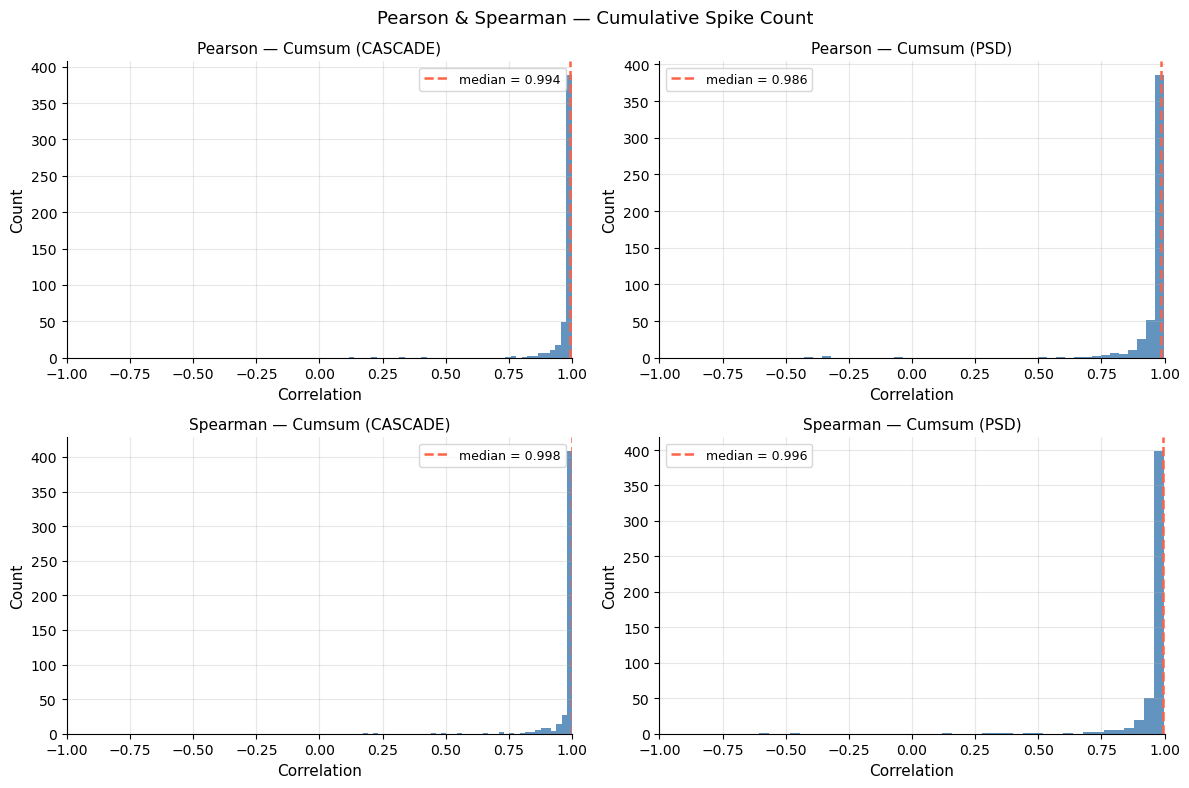

gof_tau_pearson_raw: n=490, median=0.992, mean=0.960
gof_tau_psd_pearson_raw: n=501, median=0.993, mean=0.965
gof_tau_spearman_raw: n=490, median=0.969, mean=0.927
gof_tau_psd_spearman_raw: n=501, median=0.968, mean=0.924


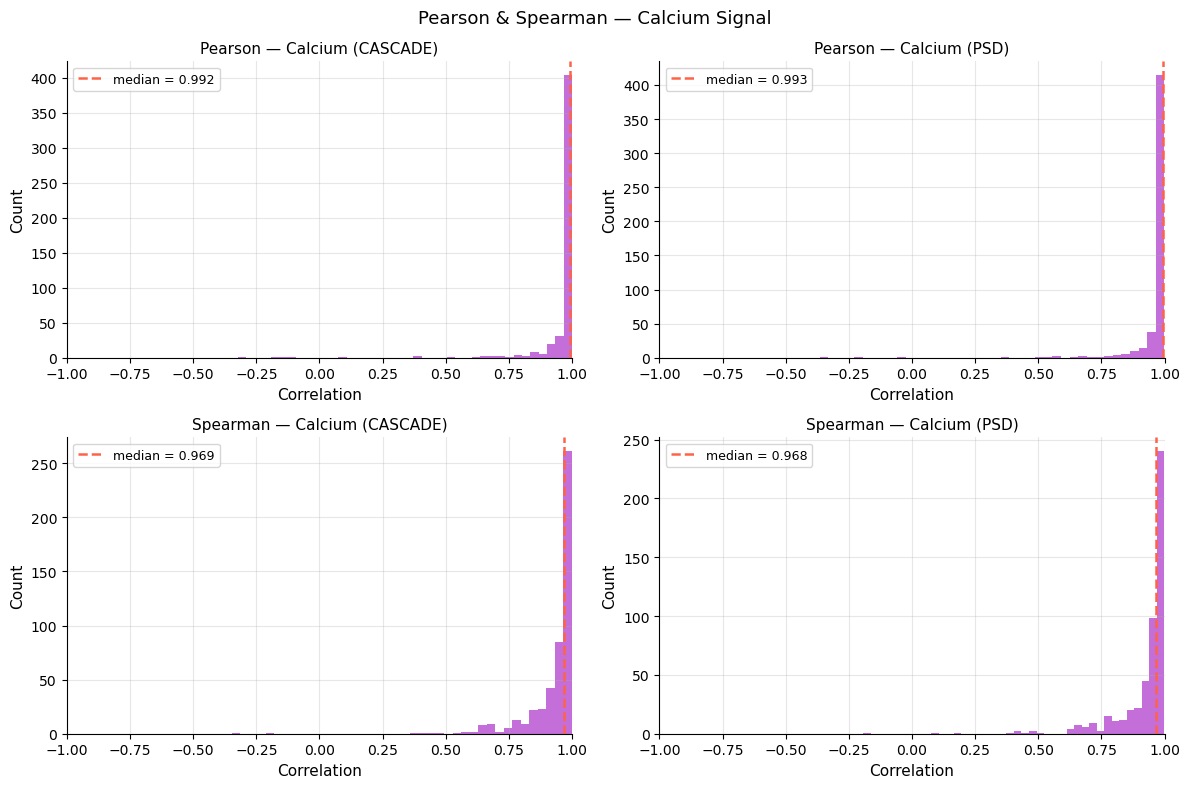

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# ── Pearson & Spearman — Cumsum (spikes) ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pairs_cumsum = [
    ('pearson_cumsum_raw',      'Pearson — Cumsum (CASCADE)'),
    ('pearson_cumsum_raw_psd',  'Pearson — Cumsum (PSD)'),
    ('spearman_cumsum_raw',     'Spearman — Cumsum (CASCADE)'),
    ('spearman_cumsum_raw_psd', 'Spearman — Cumsum (PSD)'),
]

for ax, (col, title) in zip(axes.flatten(), pairs_cumsum):
    vals = df_measurements[col].dropna()
    ax.hist(vals, bins=40, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(np.median(vals), color='tomato', linewidth=1.8, linestyle='--',
               label=f'median = {np.median(vals):.3f}')
    ax.set_xlabel('Correlation', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-1, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    print(f"{col}: n={len(vals)}, median={np.median(vals):.3f}, mean={np.mean(vals):.3f}")

plt.suptitle('Pearson & Spearman — Cumulative Spike Count', fontsize=13)
plt.tight_layout()
plt.show()

# ── Pearson & Spearman — Calcium signal ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pairs_calcium = [
    ('gof_tau_pearson_raw',      'Pearson — Calcium (CASCADE)'),
    ('gof_tau_psd_pearson_raw',  'Pearson — Calcium (PSD)'),
    ('gof_tau_spearman_raw',     'Spearman — Calcium (CASCADE)'),
    ('gof_tau_psd_spearman_raw', 'Spearman — Calcium (PSD)'),
]

for ax, (col, title) in zip(axes.flatten(), pairs_calcium):
    vals = df_measurements[col].dropna()
    ax.hist(vals, bins=40, color='mediumorchid', edgecolor='none', alpha=0.85)
    ax.axvline(np.median(vals), color='tomato', linewidth=1.8, linestyle='--',
               label=f'median = {np.median(vals):.3f}')
    ax.set_xlabel('Correlation', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-1, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    print(f"{col}: n={len(vals)}, median={np.median(vals):.3f}, mean={np.mean(vals):.3f}")

plt.suptitle('Pearson & Spearman — Calcium Signal', fontsize=13)
plt.tight_layout()
plt.show()


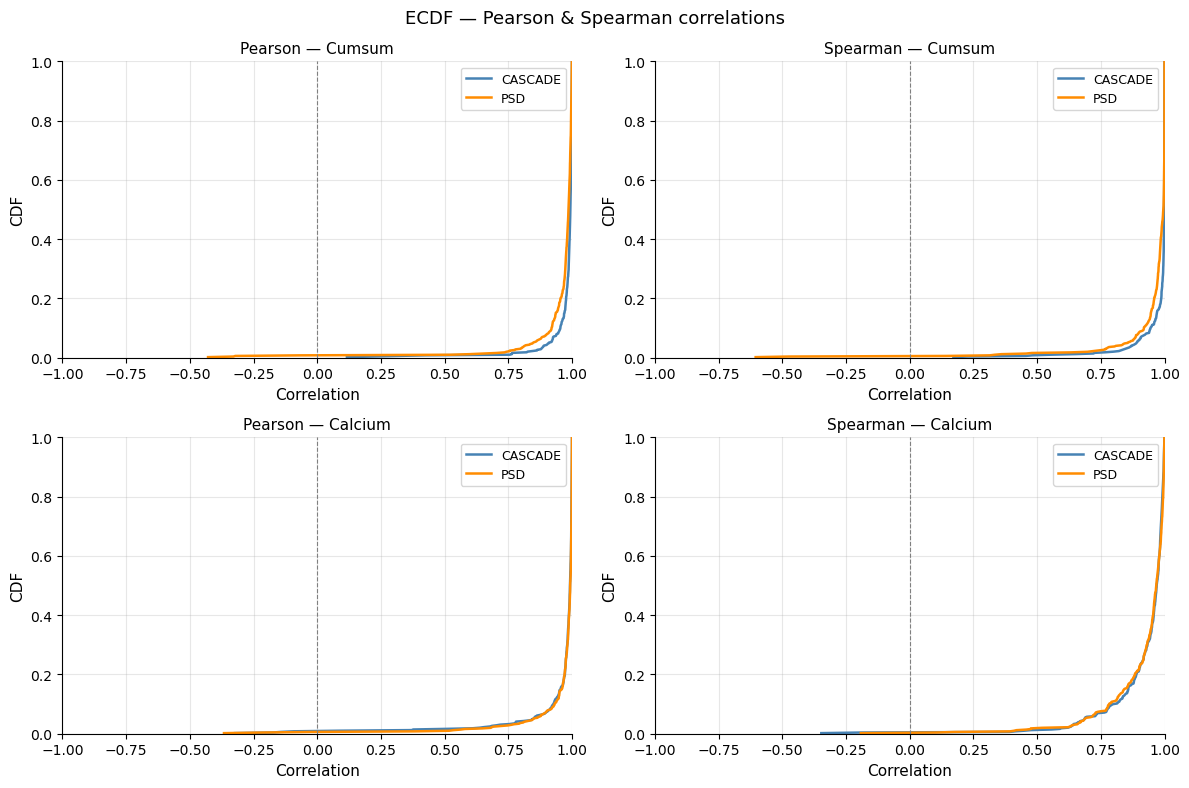

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ecdf(ax, vals, label, color):
    sorted_vals = np.sort(vals.dropna())
    y = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.plot(sorted_vals, y, label=label, color=color, linewidth=1.8)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

groups = [
    (axes[0, 0], 'pearson_cumsum_raw',      'pearson_cumsum_raw_psd',     'Pearson — Cumsum'),
    (axes[0, 1], 'spearman_cumsum_raw',     'spearman_cumsum_raw_psd',    'Spearman — Cumsum'),
    (axes[1, 0], 'gof_tau_pearson_raw',     'gof_tau_psd_pearson_raw',    'Pearson — Calcium'),
    (axes[1, 1], 'gof_tau_spearman_raw',    'gof_tau_psd_spearman_raw',   'Spearman — Calcium'),
]

for ax, col_cas, col_psd, title in groups:
    plot_ecdf(ax, df_measurements[col_cas], 'CASCADE', 'steelblue')
    plot_ecdf(ax, df_measurements[col_psd], 'PSD',     'darkorange')
    ax.set_xlabel('Correlation', fontsize=11)
    ax.set_ylabel('CDF', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('ECDF — Pearson & Spearman correlations', fontsize=13)
plt.tight_layout()
plt.show()


Calcium sweep: 100%|██████████| 11/11 [02:07<00:00, 11.61s/it]


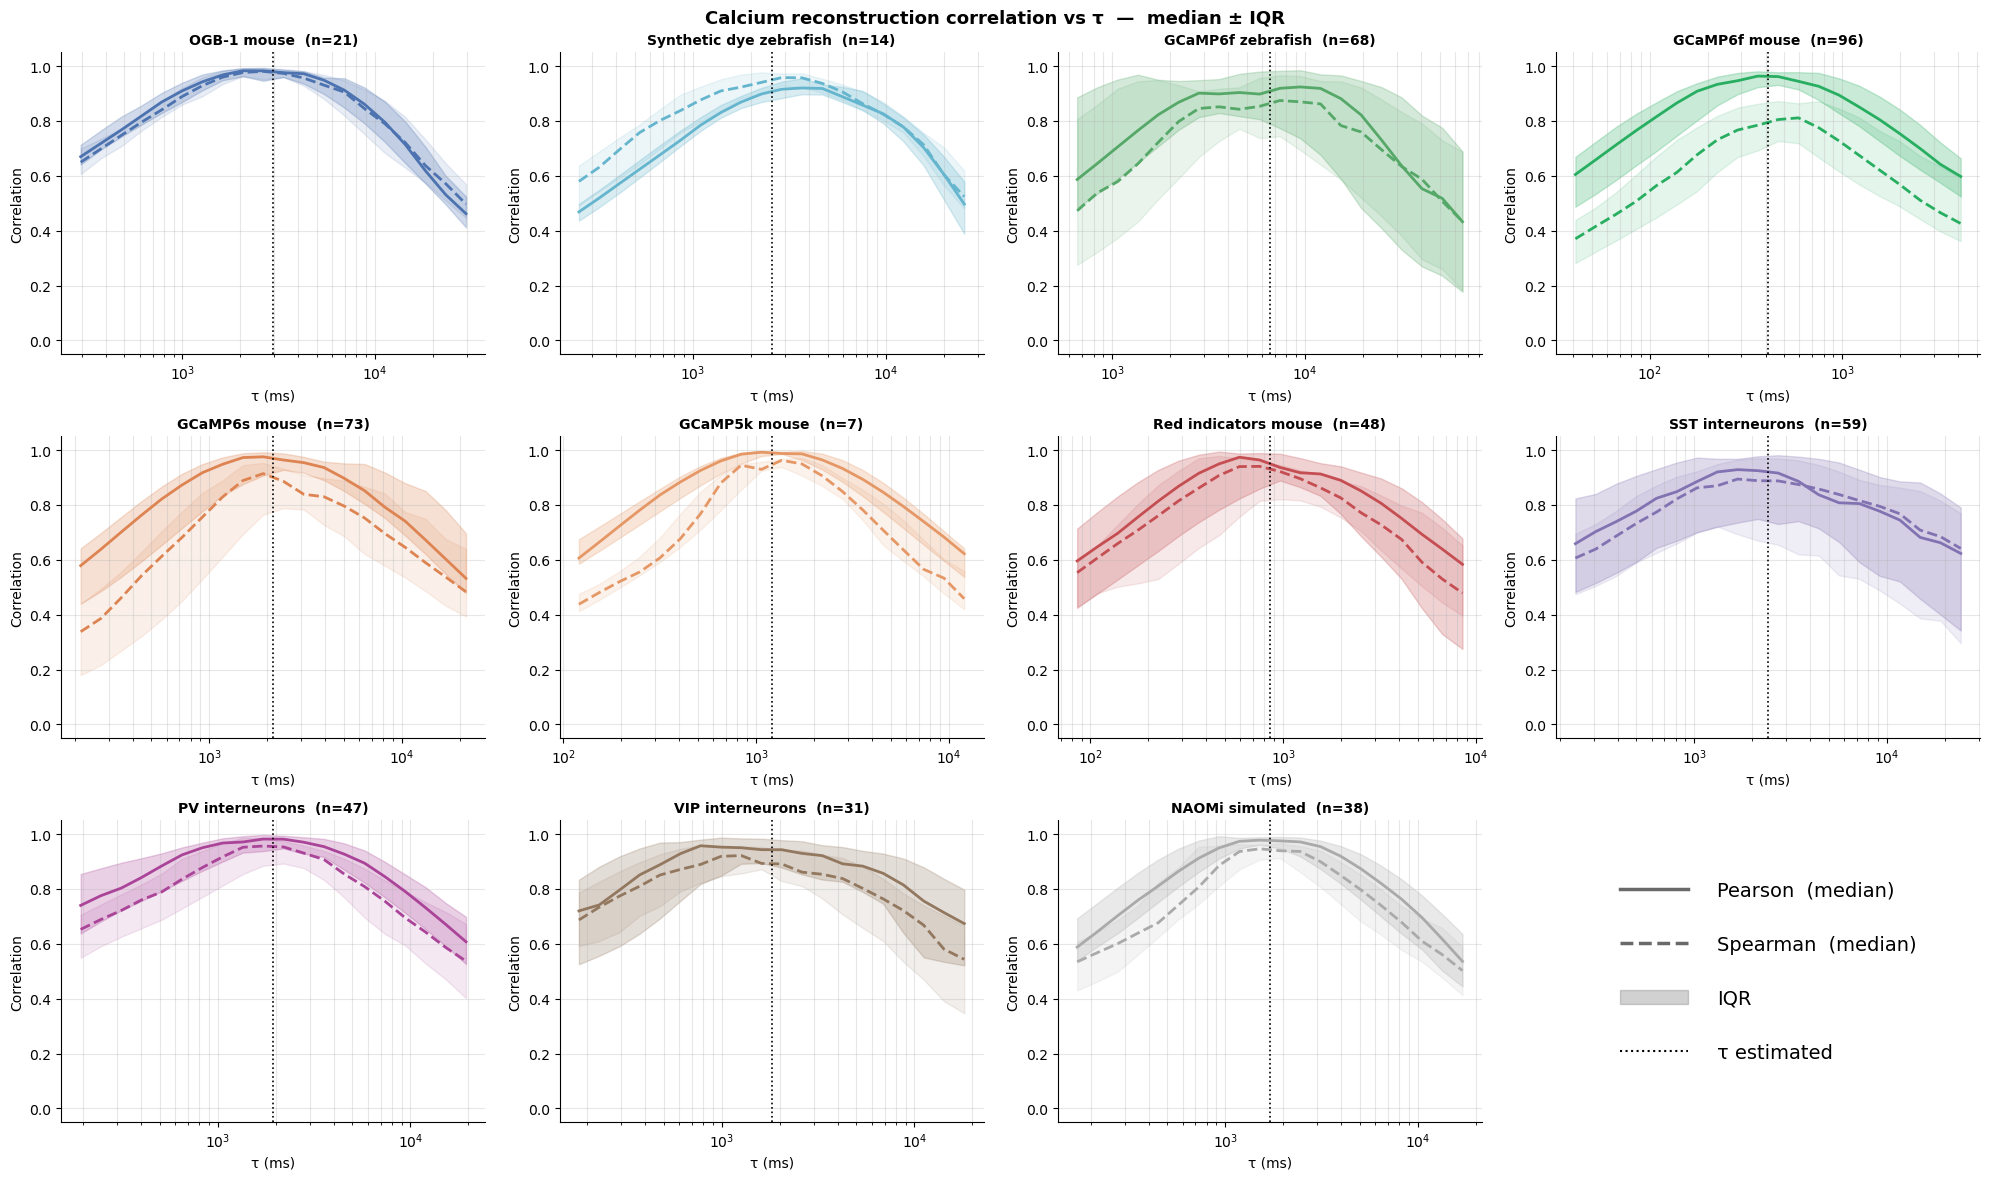

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict

# ── Group definitions ─────────────────────────────────────────────────────────
groups = {
    "OGB-1 mouse":             ["DS01-OGB1-m-V1", "DS02-OGB1-2-m-V1"],
    "Synthetic dye zebrafish": ["DS04-OGB1-zf-pDp", "DS05-Cal520-zf-pDp"],
    "GCaMP6f zebrafish":       ["DS06-GCaMP6f-zf-aDp", "DS07-GCaMP6f-zf-dD", "DS08-GCaMP6f-zf-OB"],
    "GCaMP6f mouse":           ["DS09-GCaMP6f-m-V1", "DS10-GCaMP6f-m-V1-neuropil-corrected",
                                "DS11-GCaMP6f-m-V1-neuropil-corrected", "X-DS09-GCaMP6f-m-V1",
                                "X-DS10-GCaMP6f-m-V1"],
    "GCaMP6s mouse":           ["DS12-GCaMP6s-m-V1-neuropil-corrected", "DS13-GCaMP6s-m-V1-neuropil-corrected",
                                "DS14-GCaMP6s-m-V1", "DS15-GCaMP6s-m-V1", "DS16-GCaMP6s-m-V1",
                                "X-DS11-GCaMP6s-m-V1", "X-DS12-GCaMP6s-m-V1"],
    "GCaMP5k mouse":           ["DS17-GCaMP5k-m-V1"],
    "Red indicators mouse":    ["DS18-R-CaMP-m-CA3", "DS19-R-CaMP-m-S1",
                                "DS20-jRCaMP1a-m-V1", "DS21-jGECO1a-m-V1"],
    "SST interneurons":        ["DS22-OGB1-m-SST-V1", "DS25-GCaMP6f-m-SST-V1"],
    "PV interneurons":         ["DS23-OGB1-m-PV-V1", "DS24-GCaMP6f-m-PV-V1", "DS27-GCaMP6f-m-PV-vivo-V1"],
    "VIP interneurons":        ["DS26-GCaMP6f-m-VIP-V1"],
    "NAOMi simulated":         ["X-NAOMi-GCaMP6f-simulated"],
}
group_colors = {
    "OGB-1 mouse":             "#4C72B0",
    "Synthetic dye zebrafish": "#64B5CD",
    "GCaMP6f zebrafish":       "#55A868",
    "GCaMP6f mouse":           "#27AE60",
    "GCaMP6s mouse":           "#DD8452",
    "GCaMP5k mouse":           "#E59866",
    "Red indicators mouse":    "#C44E52",
    "SST interneurons":        "#8172B2",
    "PV interneurons":         "#AA4499",
    "VIP interneurons":        "#937860",
    "NAOMi simulated":         "#AAAAAA",
}
groups_order = list(groups.keys())
ds_to_group  = {ds: grp for grp, dss in groups.items() for ds in dss}

def get_dataset_name(nd):
    name = nd.get('dataset_name')
    if not name and 'original_neuron' in nd:
        name = nd['original_neuron'].get('dataset_name')
    return name or 'Unknown'

group_indices = defaultdict(list)
for i, nd in enumerate(neurons):
    grp = ds_to_group.get(get_dataset_name(nd), 'Unknown')
    group_indices[grp].append(i)

def safe_pearson(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(pearsonr(a, b)[0])
    except: return np.nan

def safe_spearman(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(spearmanr(a, b)[0])
    except: return np.nan

# ── Computation: calcium — ±1 decade ─────────────────────────────────────────
group_results_cal = {}

for grp in tqdm(groups_order, desc="Calcium sweep"):
    indices = group_indices[grp]
    if not indices: continue

    tau_ms_vals = [neurons[i].get('tau_ms') for i in indices]
    tau_ms_vals = [t for t in tau_ms_vals if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals: continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 10),
                                np.log10(median_tau_ms * 10), 20)
    n_tau = len(tau_sweep_ms)
    n_neu = len(indices)
    p_cal = np.full((n_neu, n_tau), np.nan)
    s_cal = np.full((n_neu, n_tau), np.nan)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        rec_spk  = nd.get('reconstructed_spikes')
        time_vec = nd.get('evenly_spaced_time')
        if original is None or rec_spk is None or time_vec is None: continue
        fs = 1.0 / (time_vec[1] - time_vec[0]) if len(time_vec) > 1 else 100.0

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                sim = simulate_calcium_from_reconstructed_spikes(rec_spk, tau_frames=tf)
                p_cal[row, col] = safe_pearson(original, sim)
                s_cal[row, col] = safe_spearman(original, sim)
            except Exception:
                pass

    group_results_cal[grp] = {
        'tau_sweep_ms': tau_sweep_ms, 'median_tau_ms': median_tau_ms,
        'p_cal': p_cal, 's_cal': s_cal, 'n_neurons': n_neu,
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols, nrows = 4, 3
fig, axes   = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat   = axes.flatten()

for ax_i, grp in enumerate(groups_order):
    ax  = axes_flat[ax_i]
    res = group_results_cal.get(grp)
    if res is None:
        ax.set_visible(False)
        continue

    color  = group_colors[grp]
    tau_ms = res['tau_sweep_ms']
    p_med  = np.nanmedian(res['p_cal'], axis=0)
    s_med  = np.nanmedian(res['s_cal'], axis=0)
    p_q25  = np.nanpercentile(res['p_cal'], 25, axis=0)
    p_q75  = np.nanpercentile(res['p_cal'], 75, axis=0)
    s_q25  = np.nanpercentile(res['s_cal'], 25, axis=0)
    s_q75  = np.nanpercentile(res['s_cal'], 75, axis=0)

    ax.fill_between(tau_ms, p_q25, p_q75, alpha=0.25, color=color)
    ax.fill_between(tau_ms, s_q25, s_q75, alpha=0.12, color=color)
    ax.plot(tau_ms, p_med, color=color, linewidth=2)
    ax.plot(tau_ms, s_med, color=color, linewidth=2, linestyle='--')
    ax.axvline(res['median_tau_ms'], color='black', linewidth=1.2, linestyle=':')

    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('τ (ms)', fontsize=10)
    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title(f"{grp}  (n={res['n_neurons']})", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend in 12th panel ──────────────────────────────────────────────────────
legend_ax = axes_flat[len(groups_order)]
legend_ax.set_visible(True)
legend_ax.axis('off')
handles = [
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, label='Pearson  (median)'),
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, linestyle='--',
                  label='Spearman  (median)'),
    mpatches.Patch(color='dimgray', alpha=0.3, label='IQR'),
    mlines.Line2D([], [], color='black', linewidth=1.5, linestyle=':', label='τ estimated'),
]
legend_ax.legend(handles=handles, loc='center', fontsize=14, frameon=False,
                 handlelength=3.5, handletextpad=1.5, labelspacing=1.8)

for ax_i in range(len(groups_order) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    'Calcium reconstruction correlation vs τ  —  median ± IQR',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


Binned cumsum sweep:   0%|          | 0/11 [00:00<?, ?it/s]

Binned cumsum sweep: 100%|██████████| 11/11 [01:24<00:00,  7.65s/it]


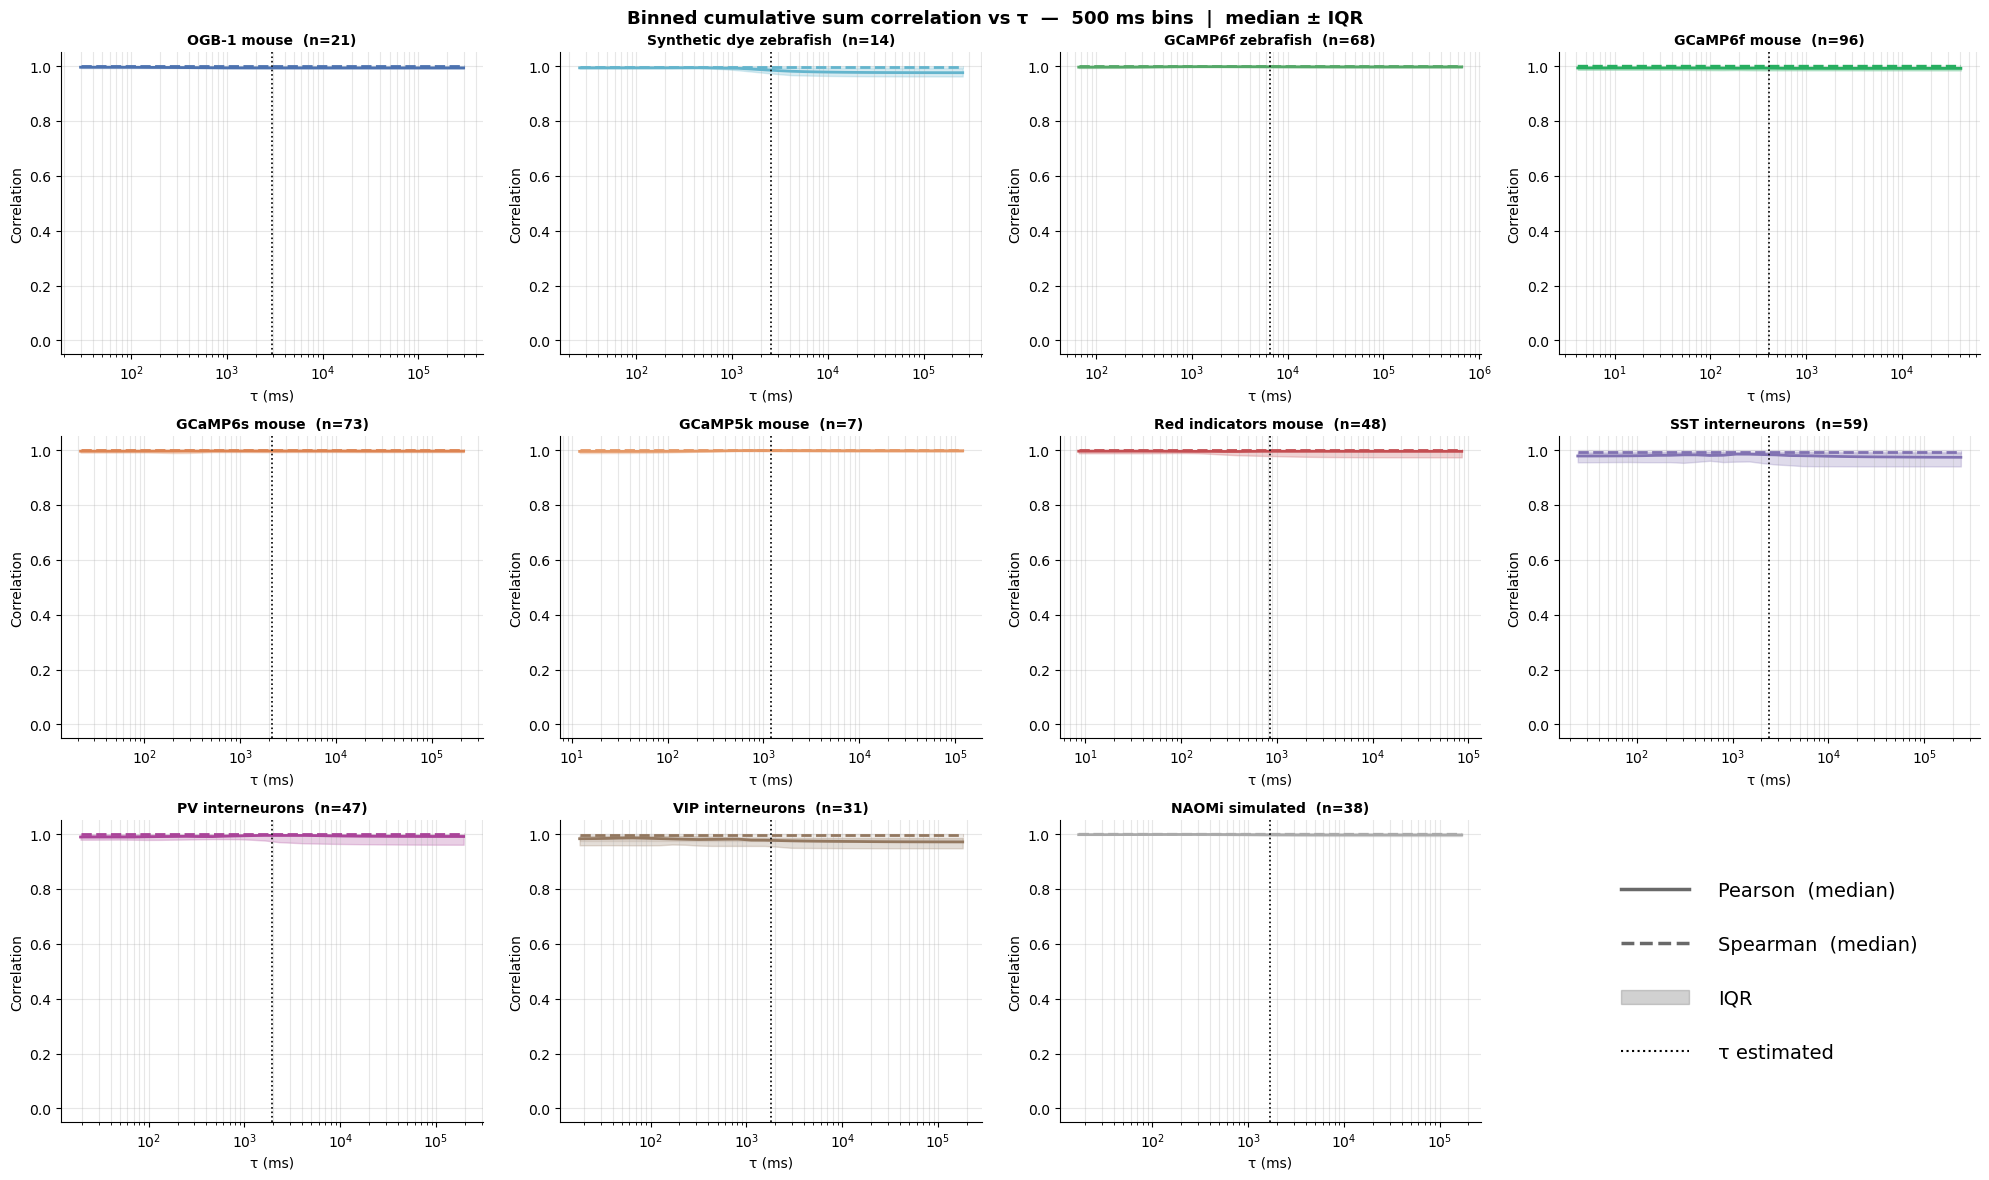

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict

# ── Group definitions ─────────────────────────────────────────────────────────
groups = {
    "OGB-1 mouse":             ["DS01-OGB1-m-V1", "DS02-OGB1-2-m-V1"],
    "Synthetic dye zebrafish": ["DS04-OGB1-zf-pDp", "DS05-Cal520-zf-pDp"],
    "GCaMP6f zebrafish":       ["DS06-GCaMP6f-zf-aDp", "DS07-GCaMP6f-zf-dD", "DS08-GCaMP6f-zf-OB"],
    "GCaMP6f mouse":           ["DS09-GCaMP6f-m-V1", "DS10-GCaMP6f-m-V1-neuropil-corrected",
                                "DS11-GCaMP6f-m-V1-neuropil-corrected", "X-DS09-GCaMP6f-m-V1",
                                "X-DS10-GCaMP6f-m-V1"],
    "GCaMP6s mouse":           ["DS12-GCaMP6s-m-V1-neuropil-corrected", "DS13-GCaMP6s-m-V1-neuropil-corrected",
                                "DS14-GCaMP6s-m-V1", "DS15-GCaMP6s-m-V1", "DS16-GCaMP6s-m-V1",
                                "X-DS11-GCaMP6s-m-V1", "X-DS12-GCaMP6s-m-V1"],
    "GCaMP5k mouse":           ["DS17-GCaMP5k-m-V1"],
    "Red indicators mouse":    ["DS18-R-CaMP-m-CA3", "DS19-R-CaMP-m-S1",
                                "DS20-jRCaMP1a-m-V1", "DS21-jGECO1a-m-V1"],
    "SST interneurons":        ["DS22-OGB1-m-SST-V1", "DS25-GCaMP6f-m-SST-V1"],
    "PV interneurons":         ["DS23-OGB1-m-PV-V1", "DS24-GCaMP6f-m-PV-V1", "DS27-GCaMP6f-m-PV-vivo-V1"],
    "VIP interneurons":        ["DS26-GCaMP6f-m-VIP-V1"],
    "NAOMi simulated":         ["X-NAOMi-GCaMP6f-simulated"],
}
group_colors = {
    "OGB-1 mouse":             "#4C72B0",
    "Synthetic dye zebrafish": "#64B5CD",
    "GCaMP6f zebrafish":       "#55A868",
    "GCaMP6f mouse":           "#27AE60",
    "GCaMP6s mouse":           "#DD8452",
    "GCaMP5k mouse":           "#E59866",
    "Red indicators mouse":    "#C44E52",
    "SST interneurons":        "#8172B2",
    "PV interneurons":         "#AA4499",
    "VIP interneurons":        "#937860",
    "NAOMi simulated":         "#AAAAAA",
}
groups_order = list(groups.keys())
ds_to_group  = {ds: grp for grp, dss in groups.items() for ds in dss}

def get_dataset_name(nd):
    name = nd.get('dataset_name')
    if not name and 'original_neuron' in nd:
        name = nd['original_neuron'].get('dataset_name')
    return name or 'Unknown'

group_indices = defaultdict(list)
for i, nd in enumerate(neurons):
    grp = ds_to_group.get(get_dataset_name(nd), 'Unknown')
    group_indices[grp].append(i)

def safe_pearson(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(pearsonr(a, b)[0])
    except: return np.nan

def safe_spearman(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(spearmanr(a, b)[0])
    except: return np.nan

BIN_MS = 500.0

# ── Computation: binned cumsum — ±2 decades ───────────────────────────────────
group_results_cumsum = {}

for grp in tqdm(groups_order, desc="Binned cumsum sweep"):
    indices = group_indices[grp]
    if not indices: continue

    tau_ms_vals = [neurons[i].get('tau_ms') for i in indices]
    tau_ms_vals = [t for t in tau_ms_vals if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals: continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 100),
                                np.log10(median_tau_ms * 100), 30)
    n_tau = len(tau_sweep_ms)
    n_neu = len(indices)
    p_cs  = np.full((n_neu, n_tau), np.nan)
    s_cs  = np.full((n_neu, n_tau), np.nan)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        time_vec = nd.get('evenly_spaced_time')
        true_spike_times = nd['original_neuron']['spikes']
        if original is None or time_vec is None: continue

        T  = len(time_vec)
        fs = 1.0 / (time_vec[1] - time_vec[0]) if T > 1 else 100.0
        bin_frames = max(1, int(round(BIN_MS * fs / 1000.0)))
        n_bins = T // bin_frames
        if n_bins < 3: continue

        sl = n_bins * bin_frames

        # bin first, then cumsum
        true_binned = get_spikes_train(true_spike_times, time_vec).astype(float)
        true_binned = true_binned[:sl].reshape(n_bins, bin_frames).sum(axis=1)
        x_true      = np.cumsum(true_binned)

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                rec        = np.clip(reconstruct_spikes(original, tau=tf), 0, None)
                rec_binned = rec[:sl].reshape(n_bins, bin_frames).sum(axis=1)
                y_rec      = np.cumsum(rec_binned)
                p_cs[row, col] = safe_pearson(x_true, y_rec)
                s_cs[row, col] = safe_spearman(x_true, y_rec)
            except Exception:
                pass

    group_results_cumsum[grp] = {
        'tau_sweep_ms': tau_sweep_ms, 'median_tau_ms': median_tau_ms,
        'p_cs': p_cs, 's_cs': s_cs, 'n_neurons': n_neu,
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols, nrows = 4, 3
fig, axes   = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat   = axes.flatten()

for ax_i, grp in enumerate(groups_order):
    ax  = axes_flat[ax_i]
    res = group_results_cumsum.get(grp)
    if res is None:
        ax.set_visible(False)
        continue

    color  = group_colors[grp]
    tau_ms = res['tau_sweep_ms']
    p_med  = np.nanmedian(res['p_cs'], axis=0)
    s_med  = np.nanmedian(res['s_cs'], axis=0)
    p_q25  = np.nanpercentile(res['p_cs'], 25, axis=0)
    p_q75  = np.nanpercentile(res['p_cs'], 75, axis=0)
    s_q25  = np.nanpercentile(res['s_cs'], 25, axis=0)
    s_q75  = np.nanpercentile(res['s_cs'], 75, axis=0)

    ax.fill_between(tau_ms, p_q25, p_q75, alpha=0.25, color=color)
    ax.fill_between(tau_ms, s_q25, s_q75, alpha=0.12, color=color)
    ax.plot(tau_ms, p_med, color=color, linewidth=2)
    ax.plot(tau_ms, s_med, color=color, linewidth=2, linestyle='--')
    ax.axvline(res['median_tau_ms'], color='black', linewidth=1.2, linestyle=':')

    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('τ (ms)', fontsize=10)
    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title(f"{grp}  (n={res['n_neurons']})", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend in 12th panel ──────────────────────────────────────────────────────
legend_ax = axes_flat[len(groups_order)]
legend_ax.set_visible(True)
legend_ax.axis('off')
handles = [
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, label='Pearson  (median)'),
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, linestyle='--',
                  label='Spearman  (median)'),
    mpatches.Patch(color='dimgray', alpha=0.3, label='IQR'),
    mlines.Line2D([], [], color='black', linewidth=1.5, linestyle=':', label='τ estimated'),
]
legend_ax.legend(handles=handles, loc='center', fontsize=14, frameon=False,
                 handlelength=3.5, handletextpad=1.5, labelspacing=1.8)

for ax_i in range(len(groups_order) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    f'Binned cumulative sum correlation vs τ  —  {BIN_MS:.0f} ms bins  |  median ± IQR',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


2D sweep: 100%|██████████| 11/11 [03:20<00:00, 18.19s/it]
/tmp/ipykernel_27770/2104379597.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


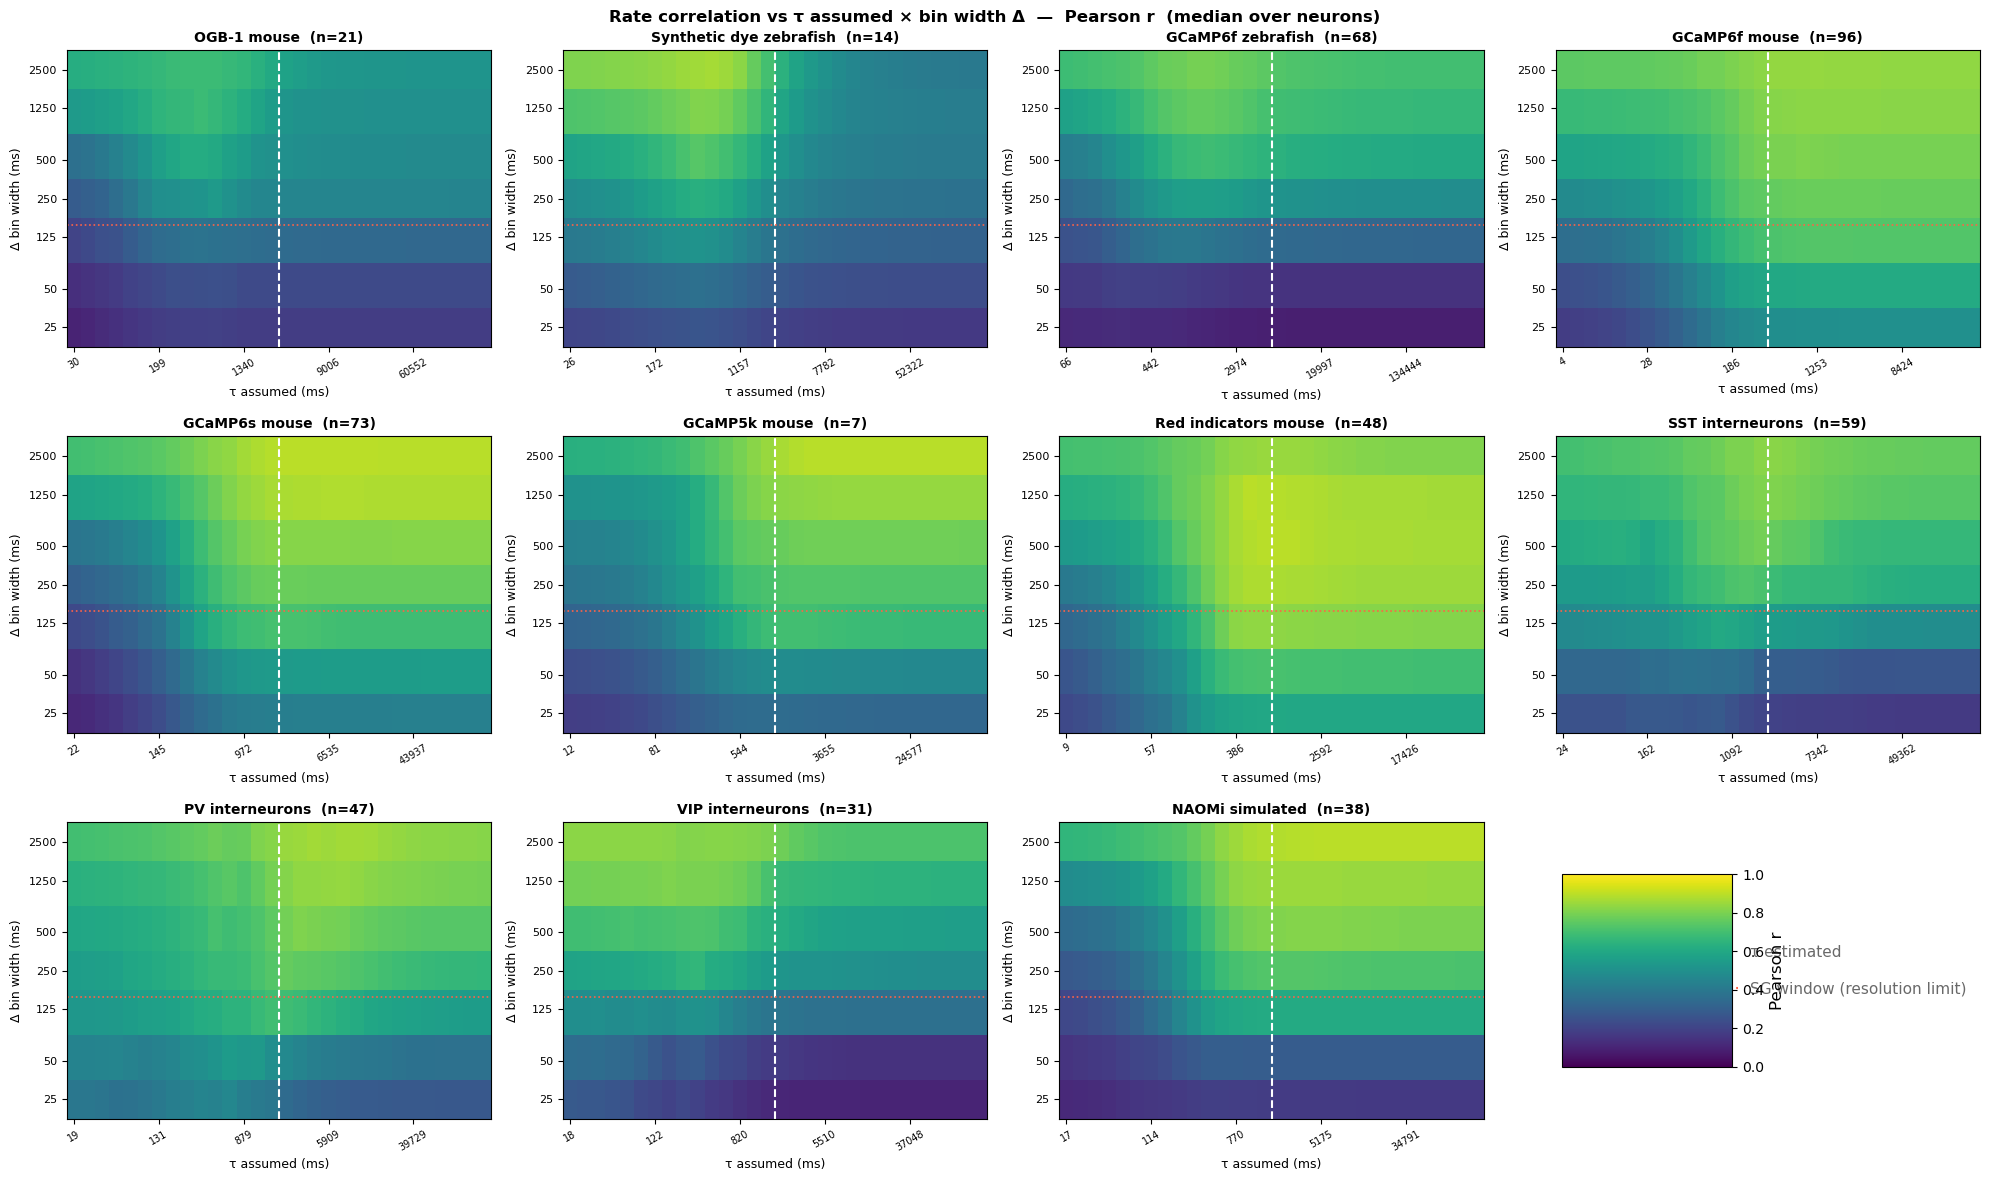

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import pearsonr
from tqdm import tqdm
from collections import defaultdict

# ── Group definitions ─────────────────────────────────────────────────────────
groups = {
    "OGB-1 mouse":             ["DS01-OGB1-m-V1", "DS02-OGB1-2-m-V1"],
    "Synthetic dye zebrafish": ["DS04-OGB1-zf-pDp", "DS05-Cal520-zf-pDp"],
    "GCaMP6f zebrafish":       ["DS06-GCaMP6f-zf-aDp", "DS07-GCaMP6f-zf-dD", "DS08-GCaMP6f-zf-OB"],
    "GCaMP6f mouse":           ["DS09-GCaMP6f-m-V1", "DS10-GCaMP6f-m-V1-neuropil-corrected",
                                "DS11-GCaMP6f-m-V1-neuropil-corrected", "X-DS09-GCaMP6f-m-V1",
                                "X-DS10-GCaMP6f-m-V1"],
    "GCaMP6s mouse":           ["DS12-GCaMP6s-m-V1-neuropil-corrected", "DS13-GCaMP6s-m-V1-neuropil-corrected",
                                "DS14-GCaMP6s-m-V1", "DS15-GCaMP6s-m-V1", "DS16-GCaMP6s-m-V1",
                                "X-DS11-GCaMP6s-m-V1", "X-DS12-GCaMP6s-m-V1"],
    "GCaMP5k mouse":           ["DS17-GCaMP5k-m-V1"],
    "Red indicators mouse":    ["DS18-R-CaMP-m-CA3", "DS19-R-CaMP-m-S1",
                                "DS20-jRCaMP1a-m-V1", "DS21-jGECO1a-m-V1"],
    "SST interneurons":        ["DS22-OGB1-m-SST-V1", "DS25-GCaMP6f-m-SST-V1"],
    "PV interneurons":         ["DS23-OGB1-m-PV-V1", "DS24-GCaMP6f-m-PV-V1", "DS27-GCaMP6f-m-PV-vivo-V1"],
    "VIP interneurons":        ["DS26-GCaMP6f-m-VIP-V1"],
    "NAOMi simulated":         ["X-NAOMi-GCaMP6f-simulated"],
}
group_colors = {
    "OGB-1 mouse":             "#4C72B0",
    "Synthetic dye zebrafish": "#64B5CD",
    "GCaMP6f zebrafish":       "#55A868",
    "GCaMP6f mouse":           "#27AE60",
    "GCaMP6s mouse":           "#DD8452",
    "GCaMP5k mouse":           "#E59866",
    "Red indicators mouse":    "#C44E52",
    "SST interneurons":        "#8172B2",
    "PV interneurons":         "#AA4499",
    "VIP interneurons":        "#937860",
    "NAOMi simulated":         "#AAAAAA",
}
groups_order = list(groups.keys())
ds_to_group  = {ds: grp for grp, dss in groups.items() for ds in dss}

def get_dataset_name(nd):
    name = nd.get('dataset_name')
    if not name and 'original_neuron' in nd:
        name = nd['original_neuron'].get('dataset_name')
    return name or 'Unknown'

group_indices = defaultdict(list)
for i, nd in enumerate(neurons):
    grp = ds_to_group.get(get_dataset_name(nd), 'Unknown')
    group_indices[grp].append(i)

def safe_pearson(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(pearsonr(a, b)[0])
    except: return np.nan

# ── Fixed bin widths in frames (at 100 Hz: 50 ms → 5 s) ──────────────────────
BIN_FRAMES = np.array([5, 10, 25, 50, 100, 250, 500], dtype=int)

# ── 2D sweep: (tau × Δ) ───────────────────────────────────────────────────────
group_results_2d = {}

for grp in tqdm(groups_order, desc="2D sweep"):
    indices = group_indices[grp]
    if not indices: continue

    tau_ms_vals = [neurons[i].get('tau_ms') for i in indices]
    tau_ms_vals = [t for t in tau_ms_vals if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals: continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 100),
                                np.log10(median_tau_ms * 100), 30)
    n_tau = len(tau_sweep_ms)
    n_bw  = len(BIN_FRAMES)
    n_neu = len(indices)
    corr_mat = np.full((n_neu, n_tau, n_bw), np.nan)

    # fs from first valid neuron (all upsampled to 100 Hz)
    fs = 100.0
    for ni in indices:
        tv = neurons[ni].get('evenly_spaced_time')
        if tv is not None and len(tv) > 1:
            fs = 1.0 / (tv[1] - tv[0])
            break
    bin_widths_ms = BIN_FRAMES * (1000.0 / fs)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        time_vec = nd.get('evenly_spaced_time')
        true_spike_times = nd['original_neuron']['spikes']
        if original is None or time_vec is None: continue

        T          = len(time_vec)
        true_train = get_spikes_train(true_spike_times, time_vec).astype(float)

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                rec = np.clip(reconstruct_spikes(original, tau=tf), 0, None)
            except Exception:
                continue

            for bi, bf in enumerate(BIN_FRAMES):
                n_bins = T // bf
                if n_bins < 3: continue
                sl     = n_bins * bf                           # recomputed per Δ
                true_b = true_train[:sl].reshape(n_bins, bf).sum(axis=1)
                rec_b  = rec       [:sl].reshape(n_bins, bf).sum(axis=1)
                corr_mat[row, col, bi] = safe_pearson(true_b, rec_b)

    group_results_2d[grp] = {
        'tau_sweep_ms' : tau_sweep_ms,
        'median_tau_ms': median_tau_ms,
        'bin_widths_ms': bin_widths_ms,
        'corr_mat'     : corr_mat,
        'n_neurons'    : n_neu,
        'fs'           : fs,
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
def log_edges(v):
    """Geometric midpoint edges for pcolormesh on a log-spaced array."""
    lv  = np.log10(v)
    mid = (lv[:-1] + lv[1:]) / 2
    return np.concatenate([[lv[0]  - (lv[1]  - lv[0])  / 2],
                            mid,
                            [lv[-1] + (lv[-1] - lv[-2]) / 2]])

ncols, nrows = 4, 3
fig, axes   = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat   = axes.flatten()

for ax_i, grp in enumerate(groups_order):
    ax  = axes_flat[ax_i]
    res = group_results_2d.get(grp)
    if res is None:
        ax.set_visible(False)
        continue

    # median over neurons → (n_tau, n_bw), transpose → (n_bw, n_tau) for rows=Δ, cols=tau
    med = np.nanmedian(res['corr_mat'], axis=0).T

    tau_ms  = res['tau_sweep_ms']
    bw_ms   = res['bin_widths_ms']
    x_edges = log_edges(tau_ms)
    y_edges = log_edges(bw_ms)
    XX, YY  = np.meshgrid(x_edges, y_edges)

    ax.pcolormesh(XX, YY, med, vmin=0, vmax=1, cmap='viridis', shading='flat')

    # mark estimated tau
    ax.axvline(np.log10(res['median_tau_ms']), color='white',
               linestyle='--', linewidth=1.5)

    # mark SG filter resolution limit
    sg_ms = 31 * (1000.0 / res['fs'])
    ax.axhline(np.log10(sg_ms), color='tomato', linestyle=':', linewidth=1.2)

    # x ticks: a few readable tau values
    tau_ticks = tau_ms[::6]
    ax.set_xticks(np.log10(tau_ticks))
    ax.set_xticklabels([f'{t:.0f}' for t in tau_ticks], fontsize=7, rotation=30)

    # y ticks: one per bin width
    ax.set_yticks(np.log10(bw_ms))
    ax.set_yticklabels([f'{bw:.0f}' for bw in bw_ms], fontsize=8)

    ax.set_xlabel('τ assumed (ms)', fontsize=9)
    ax.set_ylabel('Δ bin width (ms)', fontsize=9)
    ax.set_title(f"{grp}  (n={res['n_neurons']})", fontsize=10, fontweight='bold')

# ── Colorbar + legend in 12th panel ──────────────────────────────────────────
legend_ax = axes_flat[len(groups_order)]
legend_ax.set_visible(True)
legend_ax.axis('off')

cax = inset_axes(legend_ax, width='40%', height='65%', loc='center left')
sm  = ScalarMappable(cmap='viridis', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Pearson r', fontsize=12)
cbar.ax.tick_params(labelsize=10)

legend_ax.legend(
    handles=[
        mlines.Line2D([], [], color='white',  linestyle='--', linewidth=2,
                      label='τ estimated', markerfacecolor='dimgray'),
        mlines.Line2D([], [], color='tomato', linestyle=':',  linewidth=1.5,
                      label='SG window (resolution limit)'),
    ],
    loc='center right', fontsize=11, frameon=False,
    handlelength=3, labelspacing=1.4, labelcolor='dimgray'
)

for ax_i in range(len(groups_order) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    'Rate correlation vs τ assumed × bin width Δ  —  Pearson r  (median over neurons)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()


Optimal bin width per group (above SG limit):
  OGB-1 mouse                     Δ = 250 ms  (tau sensitivity = 0.254)
  Synthetic dye zebrafish         Δ = 2500 ms  (tau sensitivity = 0.460)
  GCaMP6f zebrafish               Δ = 500 ms  (tau sensitivity = 0.265)
  GCaMP6f mouse                   Δ = 250 ms  (tau sensitivity = 0.296)
  GCaMP6s mouse                   Δ = 250 ms  (tau sensitivity = 0.470)
  GCaMP5k mouse                   Δ = 500 ms  (tau sensitivity = 0.349)
  Red indicators mouse            Δ = 250 ms  (tau sensitivity = 0.471)
  SST interneurons                Δ = 500 ms  (tau sensitivity = 0.193)
  PV interneurons                 Δ = 250 ms  (tau sensitivity = 0.213)
  VIP interneurons                Δ = 250 ms  (tau sensitivity = 0.173)
  NAOMi simulated                 Δ = 500 ms  (tau sensitivity = 0.468)


Optimal bin sweep: 100%|██████████| 11/11 [01:52<00:00, 10.19s/it]


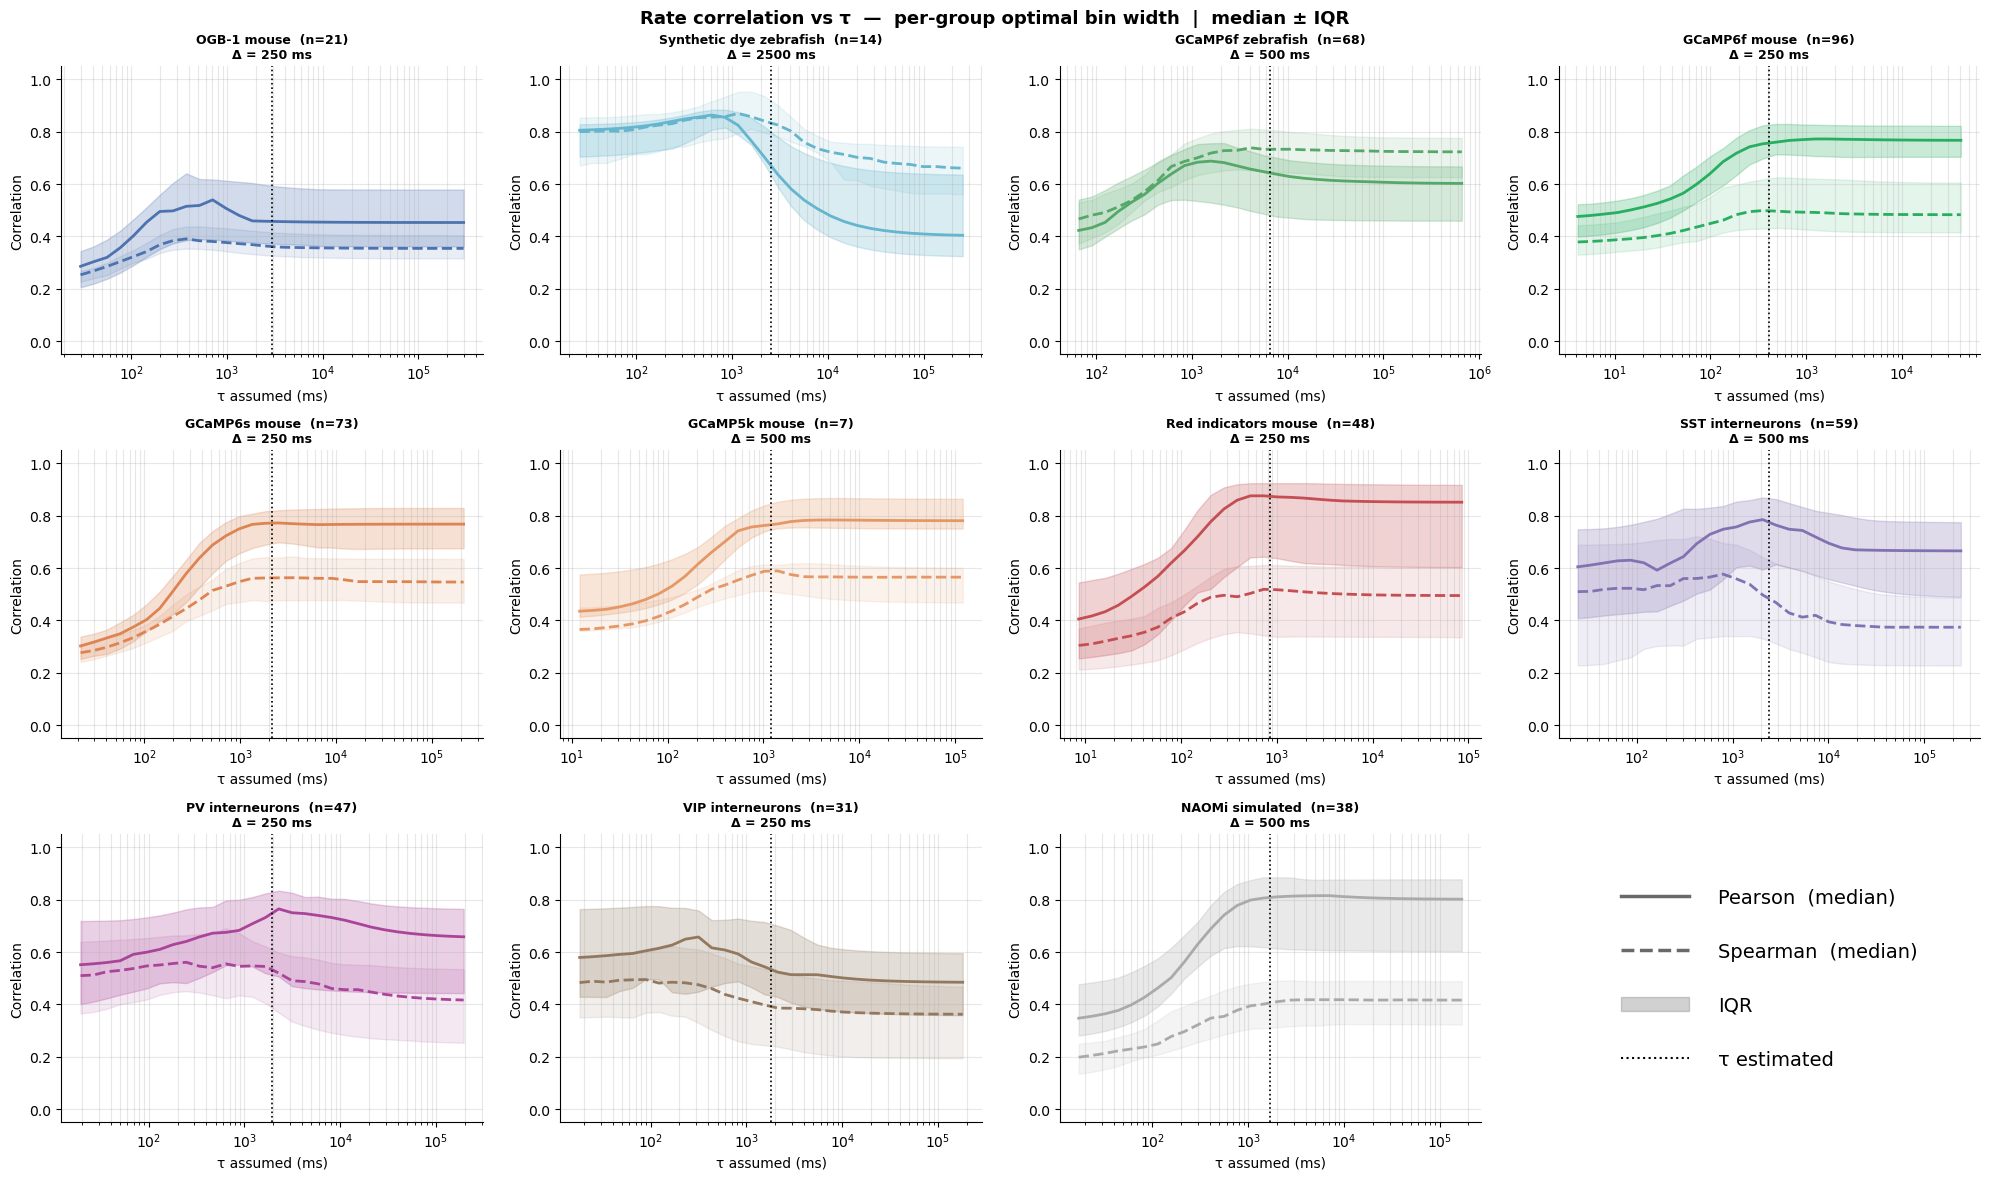

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict

# depends on: group_results_2d, BIN_FRAMES  (from heatmap cell)

def safe_pearson(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(pearsonr(a, b)[0])
    except: return np.nan

def safe_spearman(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(spearmanr(a, b)[0])
    except: return np.nan

SG_FRAMES = 31   # resolution limit of the Savitzky-Golay derivative

# ── Step 1: find optimal bin width per group ──────────────────────────────────
optimal_bins = {}

print("Optimal bin width per group (above SG limit):")
for grp, res in group_results_2d.items():
    med = np.nanmedian(res['corr_mat'], axis=0)          # (n_tau, n_bw)
    tau_range = np.nanmax(med, axis=0) - np.nanmin(med, axis=0)   # (n_bw,)

    # only consider bins at or above SG window
    valid = (BIN_FRAMES >= SG_FRAMES)
    tau_range_valid = np.where(valid, tau_range, -np.inf)
    best_bi = int(np.argmax(tau_range_valid))

    optimal_bins[grp] = {
        'bin_frames': int(BIN_FRAMES[best_bi]),
        'bin_ms'    : float(res['bin_widths_ms'][best_bi]),
        'tau_range' : float(tau_range[best_bi]),
    }
    print(f"  {grp:<30s}  Δ = {res['bin_widths_ms'][best_bi]:.0f} ms"
          f"  (tau sensitivity = {tau_range[best_bi]:.3f})")

# ── Step 2: recompute tau sweep at optimal bin — adds Spearman ────────────────
group_results_optimal = {}

for grp in tqdm(groups_order, desc="Optimal bin sweep"):
    opt     = optimal_bins.get(grp)
    indices = group_indices.get(grp, [])
    if opt is None or not indices: continue

    bf = opt['bin_frames']

    tau_ms_vals = [neurons[i].get('tau_ms') for i in indices]
    tau_ms_vals = [t for t in tau_ms_vals if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals: continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 100),
                                np.log10(median_tau_ms * 100), 30)
    n_tau = len(tau_sweep_ms)
    n_neu = len(indices)
    p_opt = np.full((n_neu, n_tau), np.nan)
    s_opt = np.full((n_neu, n_tau), np.nan)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        time_vec = nd.get('evenly_spaced_time')
        true_spike_times = nd['original_neuron']['spikes']
        if original is None or time_vec is None: continue

        T  = len(time_vec)
        fs = 1.0 / (time_vec[1] - time_vec[0]) if T > 1 else 100.0

        n_bins = T // bf
        if n_bins < 3: continue
        sl = n_bins * bf

        true_train = get_spikes_train(true_spike_times, time_vec).astype(float)
        true_b     = true_train[:sl].reshape(n_bins, bf).sum(axis=1)

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                rec   = np.clip(reconstruct_spikes(original, tau=tf), 0, None)
                rec_b = rec[:sl].reshape(n_bins, bf).sum(axis=1)
                p_opt[row, col] = safe_pearson(true_b, rec_b)
                s_opt[row, col] = safe_spearman(true_b, rec_b)
            except Exception:
                pass

    group_results_optimal[grp] = {
        'tau_sweep_ms' : tau_sweep_ms,
        'median_tau_ms': median_tau_ms,
        'p_opt'        : p_opt,
        's_opt'        : s_opt,
        'n_neurons'    : n_neu,
        'bin_ms'       : opt['bin_ms'],
    }

# ── Step 3: plot ──────────────────────────────────────────────────────────────
ncols, nrows = 4, 3
fig, axes   = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat   = axes.flatten()

for ax_i, grp in enumerate(groups_order):
    ax  = axes_flat[ax_i]
    res = group_results_optimal.get(grp)
    if res is None:
        ax.set_visible(False)
        continue

    color  = group_colors[grp]
    tau_ms = res['tau_sweep_ms']

    p_med = np.nanmedian(res['p_opt'], axis=0)
    s_med = np.nanmedian(res['s_opt'], axis=0)
    p_q25 = np.nanpercentile(res['p_opt'], 25, axis=0)
    p_q75 = np.nanpercentile(res['p_opt'], 75, axis=0)
    s_q25 = np.nanpercentile(res['s_opt'], 25, axis=0)
    s_q75 = np.nanpercentile(res['s_opt'], 75, axis=0)

    ax.fill_between(tau_ms, p_q25, p_q75, alpha=0.25, color=color)
    ax.fill_between(tau_ms, s_q25, s_q75, alpha=0.12, color=color)
    ax.plot(tau_ms, p_med, color=color, linewidth=2)
    ax.plot(tau_ms, s_med, color=color, linewidth=2, linestyle='--')
    ax.axvline(res['median_tau_ms'], color='black', linewidth=1.2, linestyle=':')

    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('τ assumed (ms)', fontsize=10)
    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title(f"{grp}  (n={res['n_neurons']})\nΔ = {res['bin_ms']:.0f} ms",
                 fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend in 12th panel ──────────────────────────────────────────────────────
legend_ax = axes_flat[len(groups_order)]
legend_ax.set_visible(True)
legend_ax.axis('off')
handles = [
    mlines.Line2D([], [], color='dimgray', linewidth=2.5,
                  label='Pearson  (median)'),
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, linestyle='--',
                  label='Spearman  (median)'),
    mpatches.Patch(color='dimgray', alpha=0.3, label='IQR'),
    mlines.Line2D([], [], color='black', linewidth=1.5, linestyle=':',
                  label='τ estimated'),
]
legend_ax.legend(handles=handles, loc='center', fontsize=14, frameon=False,
                 handlelength=3.5, handletextpad=1.5, labelspacing=1.8)

for ax_i in range(len(groups_order) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    'Rate correlation vs τ  —  per-group optimal bin width  |  median ± IQR',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


Selected bin width per group:
  OGB-1 mouse                     Δ = 2500 ms   peak_r = 0.683   tau_range = 0.166
  Synthetic dye zebrafish         Δ = 2500 ms   peak_r = 0.864   tau_range = 0.460
  GCaMP6f zebrafish               Δ = 2500 ms   peak_r = 0.793   tau_range = 0.105
  GCaMP6f mouse                   Δ = 1250 ms   peak_r = 0.828   tau_range = 0.155
  GCaMP6s mouse                   Δ = 2500 ms   peak_r = 0.898   tau_range = 0.200
  GCaMP5k mouse                   Δ = 2500 ms   peak_r = 0.894   tau_range = 0.263
  Red indicators mouse            Δ = 500 ms   peak_r = 0.898   tau_range = 0.360
  SST interneurons                Δ = 2500 ms   peak_r = 0.824   tau_range = 0.125
  PV interneurons                 Δ = 2500 ms   peak_r = 0.863   tau_range = 0.166
  VIP interneurons                Δ = 2500 ms   peak_r = 0.828   tau_range = 0.112
  NAOMi simulated                 Δ = 2500 ms   peak_r = 0.896   tau_range = 0.242


Selected bin sweep:   0%|          | 0/11 [00:00<?, ?it/s]

Selected bin sweep: 100%|██████████| 11/11 [01:36<00:00,  8.75s/it]


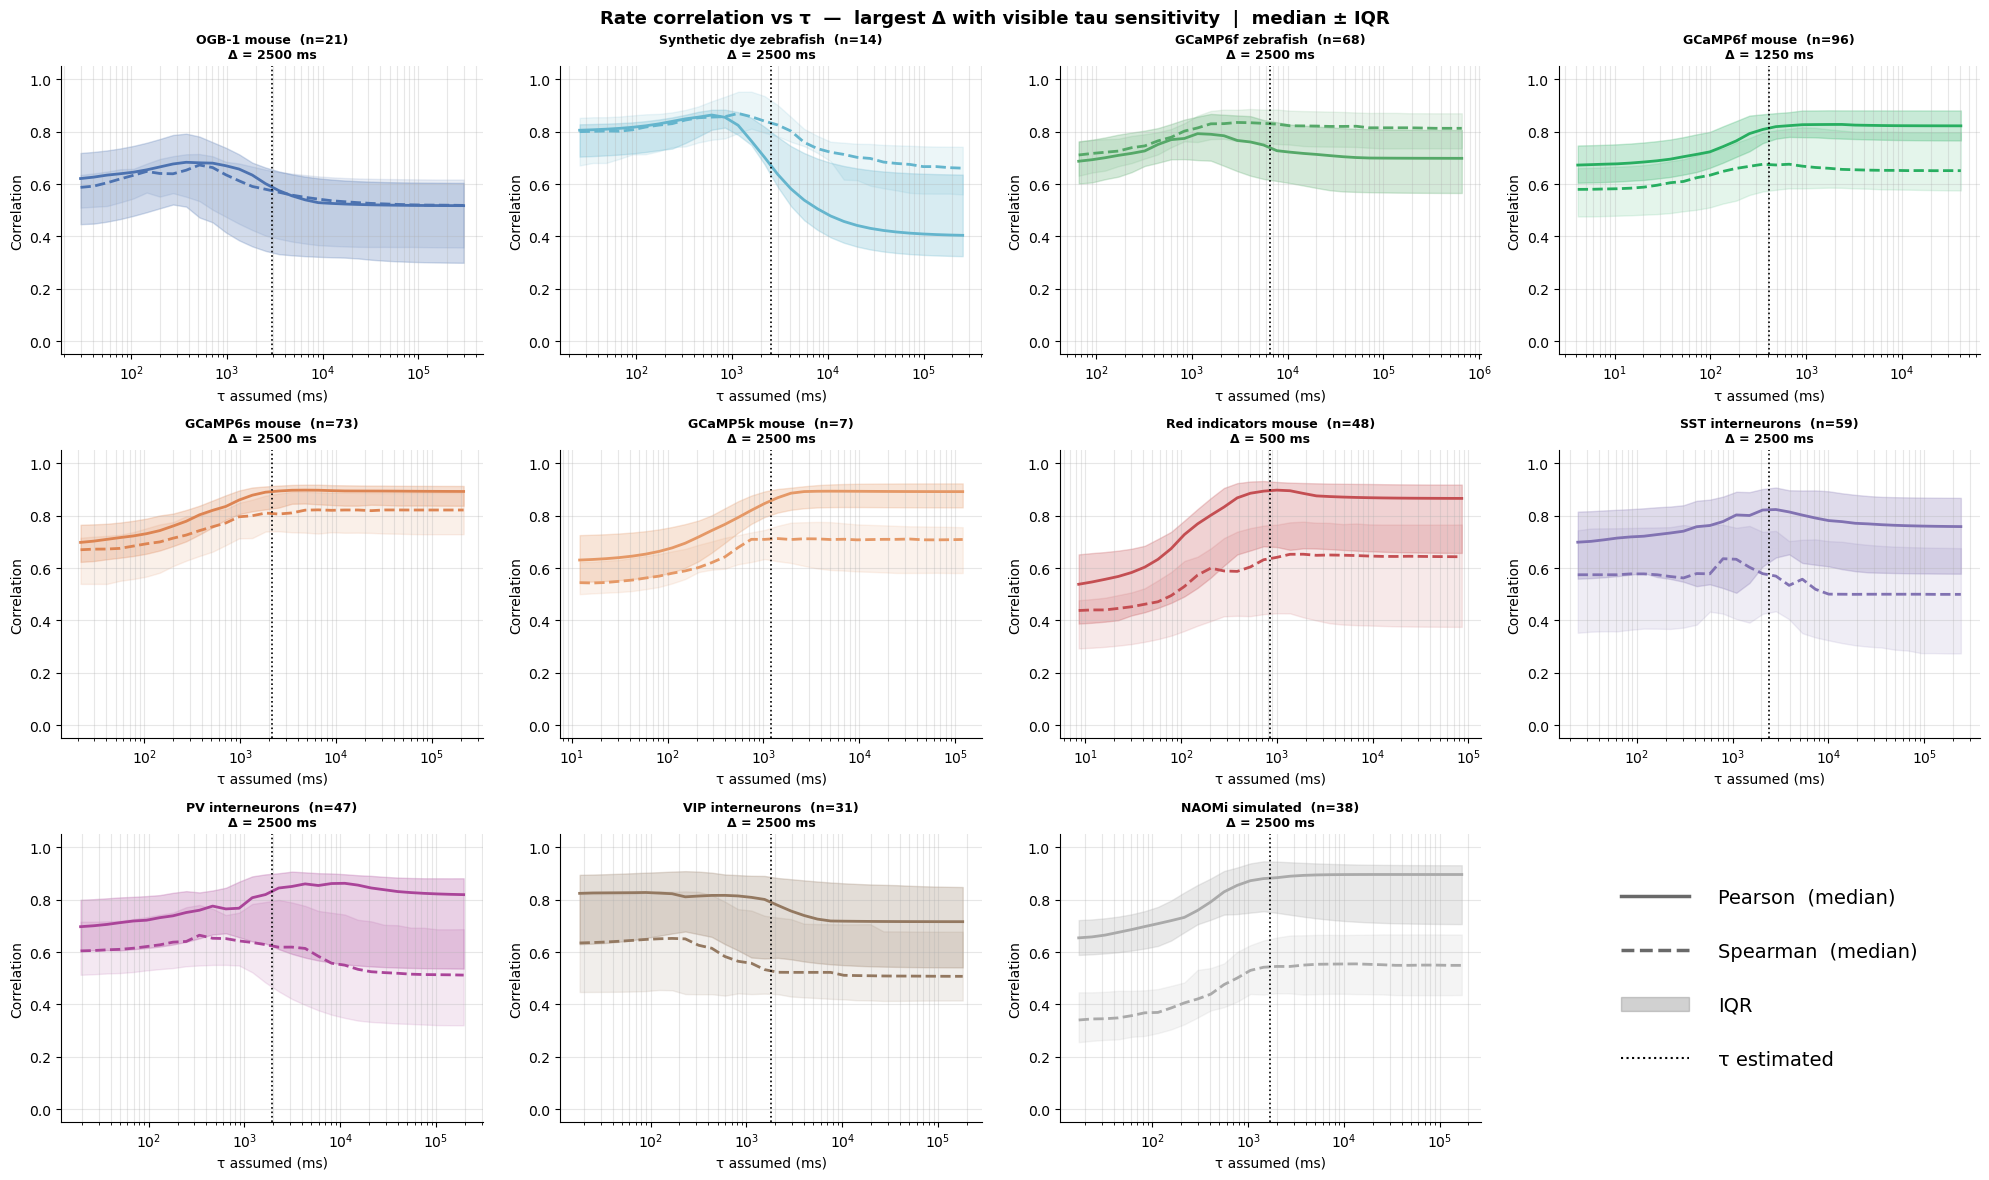

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict

# depends on: group_results_2d, BIN_FRAMES (from heatmap cell)

def safe_pearson(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(pearsonr(a, b)[0])
    except: return np.nan

def safe_spearman(a, b):
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0: return np.nan
    try: return float(spearmanr(a, b)[0])
    except: return np.nan

SG_FRAMES       = 31
SENSITIVITY_MIN = 0.1   # minimum tau_range to be considered "not flat"

# ── Step 1: largest bin that is still not flat ────────────────────────────────
selected_bins = {}

print("Selected bin width per group:")
for grp, res in group_results_2d.items():
    med       = np.nanmedian(res['corr_mat'], axis=0)   # (n_tau, n_bw)
    peak_corr = np.nanmax(med, axis=0)                  # (n_bw,)
    tau_range = np.nanmax(med, axis=0) - np.nanmin(med, axis=0)   # (n_bw,)

    # valid = above SG limit AND shows meaningful tau variation
    valid = (BIN_FRAMES >= SG_FRAMES) & (tau_range >= SENSITIVITY_MIN)

    if not valid.any():
        # fallback: smallest bin above SG limit
        valid = BIN_FRAMES >= SG_FRAMES

    # among valid bins, pick the one with highest peak correlation (= largest bin)
    best_bi = int(np.argmax(np.where(valid, peak_corr, -np.inf)))

    selected_bins[grp] = {
        'bin_frames': int(BIN_FRAMES[best_bi]),
        'bin_ms'    : float(res['bin_widths_ms'][best_bi]),
    }
    print(f"  {grp:<30s}  Δ = {res['bin_widths_ms'][best_bi]:.0f} ms"
          f"   peak_r = {peak_corr[best_bi]:.3f}"
          f"   tau_range = {tau_range[best_bi]:.3f}")

# ── Step 2: recompute tau sweep at selected bin ───────────────────────────────
group_results_selected = {}

for grp in tqdm(groups_order, desc="Selected bin sweep"):
    sel     = selected_bins.get(grp)
    indices = group_indices.get(grp, [])
    if sel is None or not indices: continue

    bf = sel['bin_frames']

    tau_ms_vals = [neurons[i].get('tau_ms') for i in indices]
    tau_ms_vals = [t for t in tau_ms_vals if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals: continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 100),
                                np.log10(median_tau_ms * 100), 30)
    n_tau = len(tau_sweep_ms)
    n_neu = len(indices)
    p_sel = np.full((n_neu, n_tau), np.nan)
    s_sel = np.full((n_neu, n_tau), np.nan)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        time_vec = nd.get('evenly_spaced_time')
        true_spike_times = nd['original_neuron']['spikes']
        if original is None or time_vec is None: continue

        T  = len(time_vec)
        fs = 1.0 / (time_vec[1] - time_vec[0]) if T > 1 else 100.0
        n_bins = T // bf
        if n_bins < 3: continue
        sl = n_bins * bf

        true_train = get_spikes_train(true_spike_times, time_vec).astype(float)
        true_b     = true_train[:sl].reshape(n_bins, bf).sum(axis=1)

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                rec   = np.clip(reconstruct_spikes(original, tau=tf), 0, None)
                rec_b = rec[:sl].reshape(n_bins, bf).sum(axis=1)
                p_sel[row, col] = safe_pearson(true_b, rec_b)
                s_sel[row, col] = safe_spearman(true_b, rec_b)
            except Exception:
                pass

    group_results_selected[grp] = {
        'tau_sweep_ms' : tau_sweep_ms,
        'median_tau_ms': median_tau_ms,
        'p_sel'        : p_sel,
        's_sel'        : s_sel,
        'n_neurons'    : n_neu,
        'bin_ms'       : sel['bin_ms'],
    }

# ── Step 3: plot ──────────────────────────────────────────────────────────────
ncols, nrows = 4, 3
fig, axes   = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat   = axes.flatten()

for ax_i, grp in enumerate(groups_order):
    ax  = axes_flat[ax_i]
    res = group_results_selected.get(grp)
    if res is None:
        ax.set_visible(False)
        continue

    color  = group_colors[grp]
    tau_ms = res['tau_sweep_ms']
    p_med  = np.nanmedian(res['p_sel'], axis=0)
    s_med  = np.nanmedian(res['s_sel'], axis=0)
    p_q25  = np.nanpercentile(res['p_sel'], 25, axis=0)
    p_q75  = np.nanpercentile(res['p_sel'], 75, axis=0)
    s_q25  = np.nanpercentile(res['s_sel'], 25, axis=0)
    s_q75  = np.nanpercentile(res['s_sel'], 75, axis=0)

    ax.fill_between(tau_ms, p_q25, p_q75, alpha=0.25, color=color)
    ax.fill_between(tau_ms, s_q25, s_q75, alpha=0.12, color=color)
    ax.plot(tau_ms, p_med, color=color, linewidth=2)
    ax.plot(tau_ms, s_med, color=color, linewidth=2, linestyle='--')
    ax.axvline(res['median_tau_ms'], color='black', linewidth=1.2, linestyle=':')

    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('τ assumed (ms)', fontsize=10)
    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title(f"{grp}  (n={res['n_neurons']})\nΔ = {res['bin_ms']:.0f} ms",
                 fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend in 12th panel ──────────────────────────────────────────────────────
legend_ax = axes_flat[len(groups_order)]
legend_ax.set_visible(True)
legend_ax.axis('off')
handles = [
    mlines.Line2D([], [], color='dimgray', linewidth=2.5,
                  label='Pearson  (median)'),
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, linestyle='--',
                  label='Spearman  (median)'),
    mpatches.Patch(color='dimgray', alpha=0.3, label='IQR'),
    mlines.Line2D([], [], color='black', linewidth=1.5, linestyle=':',
                  label='τ estimated'),
]
legend_ax.legend(handles=handles, loc='center', fontsize=14, frameon=False,
                 handlelength=3.5, handletextpad=1.5, labelspacing=1.8)

for ax_i in range(len(groups_order) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    'Rate correlation vs τ  —  largest Δ with visible tau sensitivity  |  median ± IQR',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import pearsonr
from tqdm import tqdm
from collections import defaultdict

# ── Bin-width sweep ───────────────────────────────────────────────────────────
bin_widths_s = np.logspace(np.log10(0.02), np.log10(5.0), 20)   # 20ms → 5s

group_results_binned = {}

for grp in tqdm(groups_order, desc="Groups"):
    indices = group_indices[grp]
    if not indices:
        continue

    # compute median tau directly — no dependency on group_results_corr
    tau_ms_vals = [neurons[i].get('tau_ms') for i in indices]
    tau_ms_vals = [t for t in tau_ms_vals if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals:
        continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 100),   # ±2 decades
                                np.log10(median_tau_ms * 100), 25)

    n_tau = len(tau_sweep_ms)
    n_bw  = len(bin_widths_s)
    n_neu = len(indices)
    corr_mat = np.full((n_neu, n_tau, n_bw), np.nan)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        time_vec = nd.get('evenly_spaced_time')
        true_spike_times = nd['original_neuron']['spikes']

        if original is None or time_vec is None:
            continue

        T  = len(time_vec)
        fs = 1.0 / (time_vec[1] - time_vec[0]) if T > 1 else 100.0
        true_train = get_spikes_train(true_spike_times, time_vec).astype(float)

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                rec = np.clip(reconstruct_spikes(original, tau=tf), 0, None)
            except Exception:
                continue

            for bi, bw in enumerate(bin_widths_s):
                bin_frames = max(1, int(round(bw * fs)))
                n_bins     = T // bin_frames
                if n_bins < 3:
                    continue
                sl     = n_bins * bin_frames
                true_b = true_train[:sl].reshape(n_bins, bin_frames).sum(axis=1)
                rec_b  = rec       [:sl].reshape(n_bins, bin_frames).sum(axis=1)
                if np.std(true_b) == 0 or np.std(rec_b) == 0:
                    continue
                try:
                    corr_mat[row, col, bi] = pearsonr(true_b, rec_b)[0]
                except Exception:
                    pass

    group_results_binned[grp] = {
        'tau_sweep_ms' : tau_sweep_ms,
        'median_tau_ms': median_tau_ms,
        'bin_widths_s' : bin_widths_s,
        'corr_mat'     : corr_mat,
        'n_neurons'    : n_neu,
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols, nrows = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat  = axes.flatten()

for ax_i, grp in enumerate(groups_order):
    ax  = axes_flat[ax_i]
    res = group_results_binned.get(grp)
    if res is None:
        ax.set_visible(False)
        continue

    med    = np.nanmedian(res['corr_mat'], axis=0).T   # (n_bw, n_tau)
    tau_ms = res['tau_sweep_ms']
    bw_s   = res['bin_widths_s']

    ax.imshow(
        med, aspect='auto', origin='lower', vmin=0, vmax=1, cmap='viridis',
        extent=[np.log10(tau_ms[0]), np.log10(tau_ms[-1]),
                np.log10(bw_s[0]),   np.log10(bw_s[-1])]
    )
    ax.axvline(np.log10(res['median_tau_ms']), color='white',
               linestyle='--', linewidth=1.5)

    ax.set_xlabel('log₁₀(τ  [ms])', fontsize=9)
    ax.set_ylabel('log₁₀(bin width [s])', fontsize=9)
    ax.set_title(f"{grp}  (n={res['n_neurons']})", fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend + shared colorbar in 12th panel ────────────────────────────────────
legend_ax = axes_flat[len(groups_order)]
legend_ax.set_visible(True)
legend_ax.axis('off')

cax = inset_axes(legend_ax, width='35%', height='70%', loc='center left')
sm  = ScalarMappable(cmap='viridis', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Pearson r', fontsize=13)
cbar.ax.tick_params(labelsize=11)

legend_ax.legend(
    handles=[mlines.Line2D([], [], color='white', linestyle='--',
                           linewidth=2, label='τ estimated',
                           markerfacecolor='dimgray')],
    loc='center right', fontsize=13, frameon=False,
    handlelength=3, handletextpad=1.2,
    labelcolor='dimgray'
)

for ax_i in range(len(groups_order) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    'Binned rate correlation  —  Pearson r vs τ and bin width  (median over neurons)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [46]:
df_measurements.to_csv('neurons_measurements.csv', index=False)

**Do not consider aftre this**

Valid neurons: 490 / 502
After removing top 5% (tau > 15982.6 ms): 465 neurons remaining


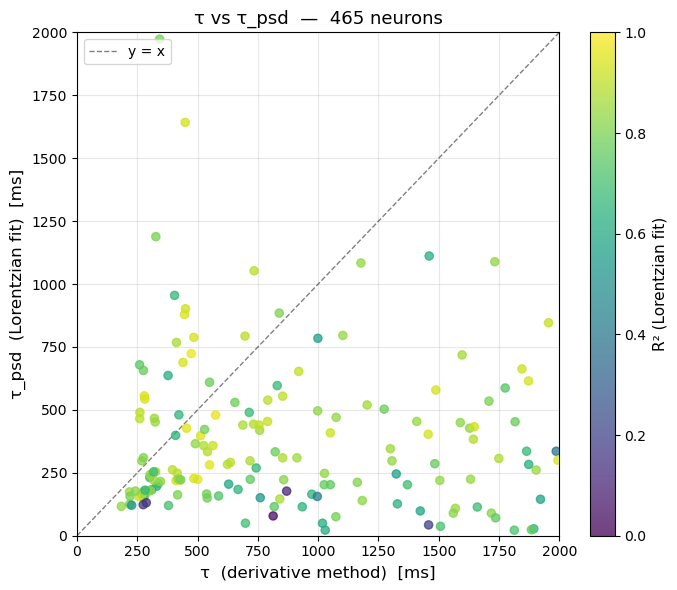

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- Collect data (tau_ms and tau_psd_ms are already in ms) ---
tau_list     = []
tau_psd_list = []
err_list     = []
r2_list      = []

for n in neurons:
    t     = n.get('tau_ms')
    t_psd = n.get('tau_psd_ms')
    info  = n.get('psd_fit_info', {})

    if (t is None or t_psd is None or
            not np.isfinite(t) or not np.isfinite(t_psd) or
            info.get('status') != 'ok'):
        continue

    tau_list.append(t)
    tau_psd_list.append(t_psd)
    err_list.append(info.get('std_tau', np.nan) * 1000)  # std_tau in sec → ms
    r2_list.append(info.get('r_squared', np.nan))

tau_arr     = np.array(tau_list)
tau_psd_arr = np.array(tau_psd_list)
err_arr     = np.array(err_list)
r2_arr      = np.array(r2_list)

print(f"Valid neurons: {len(tau_arr)} / {len(neurons)}")

# --- Remove top 5% outliers based on tau ---
threshold = np.percentile(tau_arr, 95)
mask = tau_arr <= threshold

tau_arr     = tau_arr[mask]
tau_psd_arr = tau_psd_arr[mask]
err_arr     = err_arr[mask]
r2_arr      = r2_arr[mask]

print(f"After removing top 5% (tau > {threshold:.1f} ms): {mask.sum()} neurons remaining")

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(tau_arr, tau_psd_arr, c=r2_arr, cmap='viridis',
                vmin=0, vmax=1, s=35, alpha=0.75, zorder=3)

#ax.errorbar(tau_arr, tau_psd_arr, yerr=err_arr, fmt='none', ecolor='gray', elinewidth=0.6, alpha=0.4, zorder=2)

lim = [0, max(tau_arr.max(), tau_psd_arr.max()) * 1.08]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.5, label='y = x')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('R² (Lorentzian fit)', fontsize=11)

ax.set_xlim(0, 2000)
ax.set_ylim(0, 2000)
ax.set_xlabel('τ  (derivative method)  [ms]', fontsize=12)
ax.set_ylabel('τ_psd  (Lorentzian fit)  [ms]', fontsize=12)
ax.set_title(f'τ vs τ_psd  —  {len(tau_arr)} neurons', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

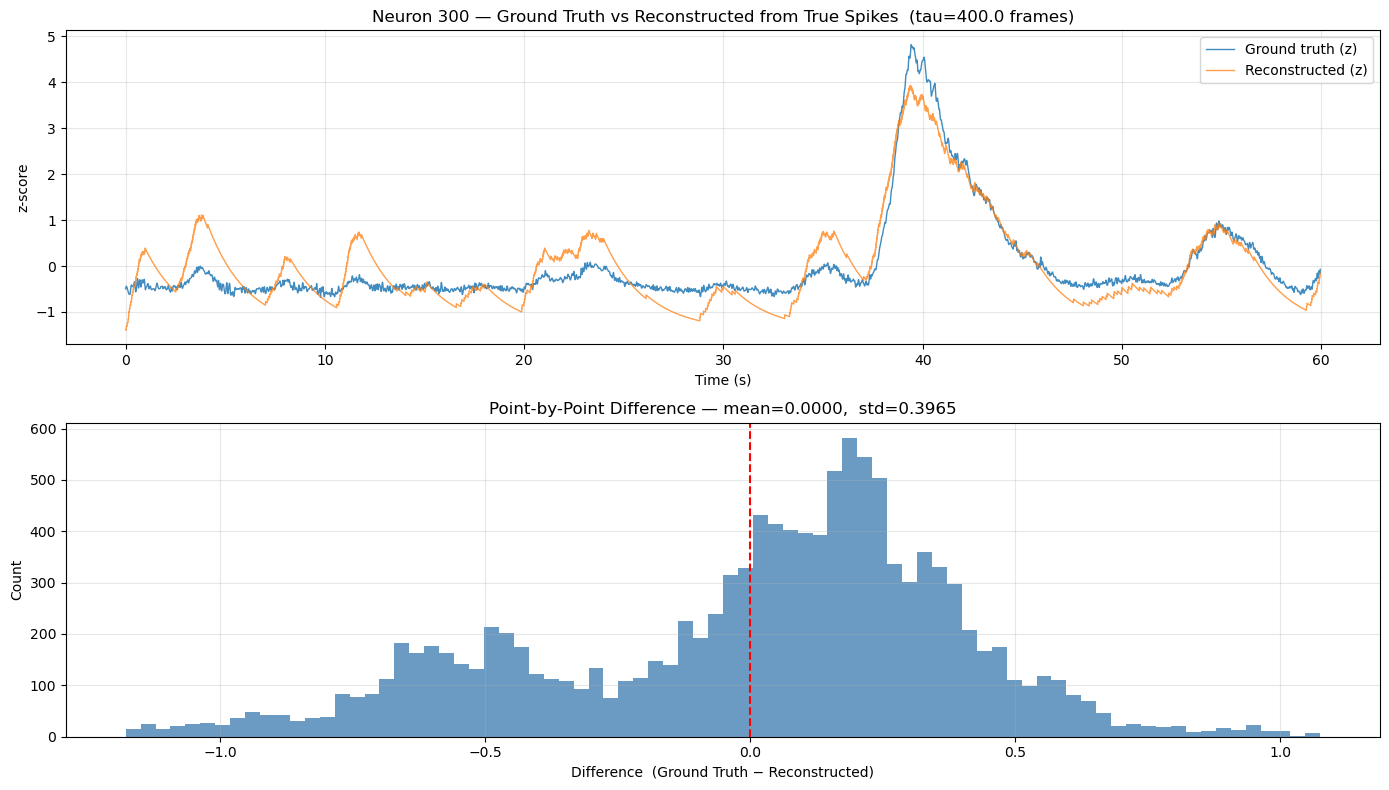

Difference   mean = 0.0000,  std = 0.3965,  max|diff| = 1.1788, tau = 400.0 frames


In [27]:
# ── Parameters (edit these) ───────────────────────────────────────────────────
neuron_number = 300
#tau           = neurons[neuron_number]['tau']   # or override: tau = 120.0
tau = 400.0

# ── Pull data ─────────────────────────────────────────────────────────────────
neuron       = neurons[neuron_number]
true_calcium = neuron['upsampled_signal']
time_grid    = neuron['evenly_spaced_time']

# ── Reconstruct calcium from true spike timestamps ────────────────────────────
rec_calcium_raw = simulate_calcium_from_true_spikes(
    true_spikes_sec = neuron['upsampled_spikes'],
    time_grid       = time_grid,
    tau_frames      = tau,
    sampling_rate   = new_rate
)

# ── Z-score both ──────────────────────────────────────────────────────────────
def zscore(x):
    return (x - x.mean()) / x.std()

true_z = zscore(true_calcium)
rec_z  = zscore(rec_calcium_raw)
diff   = true_z - rec_z

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_grid, true_z, label='Ground truth (z)', alpha=0.85, lw=1)
axes[0].plot(time_grid, rec_z,  label='Reconstructed (z)', alpha=0.75, lw=1)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('z-score')
axes[0].set_title(f'Neuron {neuron_number} — Ground Truth vs Reconstructed from True Spikes  (tau={tau:.1f} frames)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(diff, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Difference  (Ground Truth − Reconstructed)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Point-by-Point Difference — mean={diff.mean():.4f},  std={diff.std():.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Difference   mean = {diff.mean():.4f},  std = {diff.std():.4f},  max|diff| = {np.abs(diff).max():.4f}, tau = {tau:.1f} frames")


this is a part just for cheking the performance of my own written simulation of forward calcium model and compare it with the scipy lfilter function. During analysis I was worried about it and wrote a function to check it.